<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/04_construction_review_indicators_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DADS5001 Mini Project
## ตัวชี้วัดเพื่อจัดลำดับการตรวจสอบโครงการจ้างก่อสร้างวงเงินไม่เกิน 500,000 บาท

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 ไม่ใช่ข้อมูลเต็มปี

Notebook นี้ใช้โครงการก่อสร้างทั้งหมดตรวจคุณภาพข้อมูลและเป็นประชากรอ้างอิง ส่วน Indicator หลักคำนวณเฉพาะ **โครงการวิธีเฉพาะเจาะจงที่มีวงเงินไม่เกิน 500,000 บาท**

ตัวชี้วัดมี 3 มิติ:

1. ส่วนต่างราคา
2. รูปแบบใกล้เส้น 500,000 บาทที่เกิดซ้ำ
3. ความสัมพันธ์ที่หน่วยงานย่อยพึ่งพาผู้รับจ้างรายเดียวสูง

> ตัวชี้วัดใช้จัดลำดับการเปิดเอกสาร ไม่ใช่ข้อสรุปว่ามีการกระทำผิด


In [43]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
from pathlib import Path

import numpy as np
import pandas as pd

# ดาวน์โหลดฟอนต์ TH Sarabun New
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# เพิ่มฟอนต์ให้ Matplotlib
fm.fontManager.addfont(
    'thsarabunnew-webfont.ttf'
)

# กำหนดฟอนต์เริ่มต้นสำหรับ Matplotlib และ Seaborn
mpl.rc(
    'font',
    family='TH Sarabun New'
)
mpl.rcParams['axes.unicode_minus'] = False

sns.set_theme(
    style='whitegrid',
    font='TH Sarabun New'
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option(
    'display.float_format',
    lambda value: f'{value:,.2f}'
)

processed_dir = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/'
    'egp-contract/processed'
)

project_path = processed_dir / 'construction_projects_2569.csv'
contract_path = processed_dir / 'construction_contracts_2569.csv'
supplier_path = processed_dir / 'construction_supplier_summary_2569.csv'

In [45]:
project_directory = processed_dir.parents[3]
figure_directory = project_directory / 'figure'
figure_directory.mkdir(parents=True, exist_ok=True)

project_data = pd.read_csv(
    project_path,
    low_memory=False
)
contract_data = pd.read_csv(
    contract_path,
    low_memory=False
)
supplier_data = pd.read_csv(
    supplier_path,
    low_memory=False
)

assert len(project_data) == 178_978
assert len(contract_data) == 180_079
assert len(supplier_data) == 33_570

print(f'Figure directory: {figure_directory}')
print(f'Project data: {project_data.shape}')
print(f'Contract data: {contract_data.shape}')
print(f'Supplier data: {supplier_data.shape}')
print('Input validation passed')


Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure
Project data: (178978, 36)
Contract data: (180079, 29)
Supplier data: (33570, 8)
Input validation passed


## 1. กรอบการวิเคราะห์

1. ตรวจ grain และผลรวมระดับโครงการ–สัญญา
2. จัดการแถวสมาชิก Joint Venture (JV) เพื่อไม่ให้นับมูลค่าซ้ำ
3. ตรวจคุณภาพราคากลาง
4. กำหนดประชากรศึกษาตามวิธีจัดซื้อและเกณฑ์วงเงิน
5. ทดสอบความไวของเกณฑ์ที่ทีมกำหนด
6. สร้าง Indicator และตรวจการซ้อนทับ
7. เลือกกรณีศึกษาสำหรับเปิดเอกสารต่อ


In [46]:
# Column names used throughout this notebook
project_id_column = 'รหัสโครงการ'
project_name_column = 'ชื่อโครงการจัดซื้อจัดจ้าง'
agency_column = 'ชื่อหน่วยงาน'
province_column = 'จังหวัด'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'
budget_column = 'วงเงินงบประมาณ (บาท)'
reference_price_column = 'ราคากลาง (บาท)'
awarded_price_column = 'ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)'
contract_number_column = 'เลขที่สัญญา'
contract_budget_column = 'วงเงินงบประมาณในสัญญา (บาท)'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'
subagency_column = 'ชื่อหน่วยงานย่อย'
announcement_date_column = 'วันที่ประกาศจัดซื้อจัดจ้าง'
transaction_date_column = 'วันที่เกิดรายการ'

In [47]:
# Study scope and analytical thresholds
specific_method_value = 'เฉพาะเจาะจง'
legal_budget_ceiling = 500_000

near_ceiling_lower_bound = 490_000
minimum_cluster_size = 3

minimum_overrun_amount = 10_000
minimum_overrun_pct = 1

minimum_supplier_projects = 10
minimum_supplier_share = 75

project_data['in_study_scope'] = (
    project_data[method_column].eq(specific_method_value)
    & project_data[budget_column].le(legal_budget_ceiling)
)

study_project_ids = set(
    project_data.loc[
        project_data['in_study_scope'],
        project_id_column
    ]
)

study_population_summary = pd.Series({
    'โครงการก่อสร้างทั้งหมด': len(project_data),
    'โครงการในกลุ่มศึกษาหลัก': project_data['in_study_scope'].sum(),
    'สัดส่วนของโครงการก่อสร้างทั้งหมด (%)': (
        project_data['in_study_scope'].mean() * 100
    )
}, name='value')

display(study_population_summary)


,value
โครงการก่อสร้างทั้งหมด,"178,978.00"
โครงการในกลุ่มศึกษาหลัก,"136,070.00"
สัดส่วนของโครงการก่อสร้างทั้งหมด (%),76.03


## 2. ตัวชี้วัดคุณภาพข้อมูล

### 2.1 การตรวจยอดและโครงสร้าง Joint Venture (JV)

กลุ่มผู้รับจ้างแบบ Joint Venture (JV) คือผู้ประกอบการหลายราย
ร่วมกันรับงานภายใต้โครงการหรือสัญญาเดียวกัน

เริ่มจากเปรียบเทียบผลรวมวงเงินระดับสัญญากับราคาที่ตกลงระดับโครงการ
โดยยอมรับผลต่างจากการปัดเศษไม่เกิน 1 บาท ก่อนแยกโครงสร้าง JV


In [48]:
contract_value_by_project = (
    contract_data
    .groupby(project_id_column)[contract_budget_column]
    .sum(min_count=1)
    .rename('contract_budget_sum')
    .reset_index()
)

project_data = (project_data.merge(contract_value_by_project, on=project_id_column, how='left'))

project_data['contract_value_difference'] = (project_data['contract_budget_sum'] - project_data[awarded_price_column])
project_data['contract_value_abs_difference'] = (project_data['contract_value_difference'].abs())
project_data['contract_value_difference_pct'] = (project_data['contract_value_difference'].div(project_data[awarded_price_column]).mul(100))
project_data['flag_contract_mismatch'] = ~np.isclose(project_data['contract_budget_sum'], project_data[awarded_price_column], rtol=0, atol=1, equal_nan=False)

In [49]:
contract_mismatch_summary = pd.Series({
    'Total projects': (
        len(project_data)
    ),
    'Matched projects': (
        (~project_data[
            'flag_contract_mismatch'
        ]).sum()
    ),
    'Mismatch projects': (
        project_data[
            'flag_contract_mismatch'
        ].sum()
    ),
    'Mismatch pct': (
        project_data[
            'flag_contract_mismatch'
        ].mean()
        * 100
    ),
    'Total absolute difference': (
        project_data.loc[
            project_data[
                'flag_contract_mismatch'
            ],
            'contract_value_abs_difference'
        ].sum()
    )
})

display(
    contract_mismatch_summary
    .to_frame(name='value')
)

contract_mismatch_cases = (
    project_data
    .loc[
        project_data[
            'flag_contract_mismatch'
        ],
        [
            project_id_column,
            'ชื่อโครงการจัดซื้อจัดจ้าง',
            'ชื่อหน่วยงาน',
            method_column,
            awarded_price_column,
            'contract_budget_sum',
            'contract_value_difference',
            'contract_value_abs_difference',
            'contract_value_difference_pct'
        ]
    ]
    .sort_values(
        'contract_value_abs_difference',
        ascending=False
    )
)

display(
    contract_mismatch_cases.head(15)
)

,value
Total projects,"178,978.00"
Matched projects,"178,616.00"
Mismatch projects,362.00
Mismatch pct,0.20
Total absolute difference,"13,234,946,092.98"


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อวิธีการจัดซื้อจัดจ้าง,ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),contract_budget_sum,contract_value_difference,contract_value_abs_difference,contract_value_difference_pct
8,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,การไฟฟ้าส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"1,813,300,000.00","3,626,600,000.00","1,813,300,000.00","1,813,300,000.00",100.00
13,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),กรมทางหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"1,299,500,000.00","2,599,000,000.00","1,299,500,000.00","1,299,500,000.00",100.00
11,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปกรณ์ โครงการพัฒนาน้ำบาดาลเพื่อความมั่นคงระดับชุมชน จำนวน ๓๐๗ แห่ง งบประ...,กรมทรัพยากรน้ำบาดาล,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"1,663,819,967.00","2,304,873,377.00","641,053,410.00","641,053,410.00",38.53
87,68059182315,ประกวดราคาจ้างก่อสร้างและติดตั้งระบบสูบน้ำพลังงานแสงอาทิตย์แบบผิวดิน พร้อมครุภัณฑ์ประกอบระบบกระจายน้ำพลังงานแสงอาทิต...,กรมการข้าว,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"408,500,000.00","817,000,000.00","408,500,000.00","408,500,000.00",100.00
136,68069048414,ประกวดราคาจ้างก่อสร้างพัฒนาระบบไมโครกริด ที่ อำเภอเมือง จังหวัดแม่ฮ่องสอน และปรับปรุงประสิทธิภาพระบบควบคุมและป้องกัน...,การไฟฟ้าส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"249,500,000.00","499,000,000.00","249,500,000.00","249,500,000.00",100.00
140,68129397164,ประกวดราคาจ้างก่อสร้างงานก่อสร้างและเพิ่มประสิทธิภาพระบบบำบัดน้ำเสีย เทศบาลนครอุดรธานี ตำบลหมากแข้ง อำเภอเมืองอุดรธา...,องค์การจัดการน้ำเสีย,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"248,562,100.00","497,124,200.00","248,562,100.00","248,562,100.00",100.00
150,69029010512,ประกวดราคาจ้างก่อสร้างก่อสร้างอาคารทันตกรรมเพื่อผู้สูงอายุและผู้ป่วยความต้องการพิเศษ คณะทันตแพทยศาสตร์ มหาวิทยาลัยเช...,มหาวิทยาลัยเชียงใหม่,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"242,800,000.00","485,600,000.00","242,800,000.00","242,800,000.00",100.00
155,68059551063,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างระบบระบายน้ำคลองลาดเป็ด ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"234,400,000.00","468,800,000.00","234,400,000.00","234,400,000.00",100.00
159,67019030895,ประกวดราคาจ้างก่อสร้างรายการที่ 19. งานจ้างตกแต่งภายในระบบประกอบอาคารและงานภูมิสถาปัตยกรรม อาคารศูนย์บริการทางการแพท...,มหาวิทยาลัยเชียงใหม่,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"224,900,000.00","449,800,000.00","224,900,000.00","224,900,000.00",100.00
188,69136000003,ประกวดราคาจ้างก่อสร้างปรับปรุงระบบจำหน่ายไฟฟ้าเป็นเคเบิลใต้ดินบริเวณถนนไตรรัตน์ ถนนสนามบิน ถนนบรรพปราการ และถนนอุตรก...,การไฟฟ้าส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"197,412,787.67","394,825,575.34","197,412,787.67","197,412,787.67",100.00


In [50]:
sample_mismatch_ids = (
    contract_mismatch_cases
    .head(5)[
        project_id_column
    ]
    .tolist()
)

sample_mismatch_rows = (
    contract_data
    .loc[
        contract_data[
            project_id_column
        ].isin(
            sample_mismatch_ids
        ),
        [
            project_id_column,
            'ชื่อโครงการจัดซื้อจัดจ้าง',
            supplier_id_column,
            supplier_name_column,
            'เลขที่สัญญา',
            contract_budget_column
        ]
    ]
    .sort_values(
        [
            project_id_column,
            'เลขที่สัญญา',
            supplier_id_column
        ]
    )
    .head(30)
)

display(sample_mismatch_rows)

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วงเงินงบประมาณในสัญญา (บาท)
9,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,0105551101940,บริษัทจำกัด บริษัท อินเตอร์ลิ้งค์ เพาเวอร์ แอนด์ เอ็นจิเนียริ่ง จำกัด(สัญญากิจการค้าร่วม),จ.ป.105/2569,"798,214,660.00"
10,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,0107547000222,บริษัทมหาชนจำกัด บริษัท อินเตอร์ลิ้งค์ คอมมิวนิเคชั่น จำกัด (มหาชน)(สัญญากิจการค้าร่วม),จ.ป.105/2569,"936,750,780.00"
11,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,0107558000211,บริษัทมหาชนจำกัด บริษัท อินเตอร์ลิ้งค์ เทเลคอม จำกัด (มหาชน)(สัญญากิจการค้าร่วม),จ.ป.105/2569,"78,334,560.00"
8,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเคเบิลใต้น้ำ 115 เควี ตามโครงการก่อสร้างสายเคเบิลใต้น้ำ 115 เควี เพื่อทด...,D888888888001,INTERLINK CONSORTIUM,จ.ป.105/2569,"1,813,300,000.00"
29,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),0105539089307,บริษัทจำกัด บริษัท ธาราวัญ คอนสตรัคชั่น จำกัด(สัญญากิจการค้าร่วม),สท.1/7/2569,"670,542,000.00"
30,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),0535560000111,บริษัทจำกัด บริษัท ชอกมลรัตน์ จำกัด(สัญญากิจการค้าร่วม),สท.1/7/2569,"616,222,900.00"
31,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),0535561000107,บริษัทจำกัด บริษัท สุนิสาจุฬารัตน์การโยธา จำกัด(สัญญากิจการค้าร่วม),สท.1/7/2569,"12,735,100.00"
28,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองใหม่ - สามแยกเข้าสนามบิน ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),D888868004228,กิจการค้าร่วม บริษัท ธาราวัญ คอนสตรัคชั่น จำกัด และ บริษัท ชอกมลรัตน์ จำกัด และ บริษัท สุนิสาจุฬารัตน์การโยธา จำกัด,สท.1/7/2569,"1,299,500,000.00"
114,68059182315,ประกวดราคาจ้างก่อสร้างและติดตั้งระบบสูบน้ำพลังงานแสงอาทิตย์แบบผิวดิน พร้อมครุภัณฑ์ประกอบระบบกระจายน้ำพลังงานแสงอาทิต...,0105560074186,บริษัทจำกัด บริษัท เอนเนอร์จี ฟอร์ ออลล์ จำกัด(สัญญากิจการค้าร่วม),สบก.สจ7/69,"139,029,050.31"
115,68059182315,ประกวดราคาจ้างก่อสร้างและติดตั้งระบบสูบน้ำพลังงานแสงอาทิตย์แบบผิวดิน พร้อมครุภัณฑ์ประกอบระบบกระจายน้ำพลังงานแสงอาทิต...,0105563098639,บริษัทจำกัด บริษัท เกรท เซิร์ฟ จำกัด(สัญญากิจการค้าร่วม),สบก.สจ7/69,"103,617,906.42"


In [51]:
mismatch_project_profile = (
    contract_data
    .loc[
        contract_data[
            project_id_column
        ].isin(
            contract_mismatch_cases[
                project_id_column
            ]
        )
    ]
    .groupby(project_id_column)
    .agg(
        row_count=(
            project_id_column,
            'size'
        ),
        supplier_count=(
            supplier_id_column,
            'nunique'
        ),
        contract_number_count=(
            'เลขที่สัญญา',
            'nunique'
        ),
        contract_budget_value_count=(
            contract_budget_column,
            'nunique'
        )
    )
    .reset_index()
)

display(
    mismatch_project_profile
    .describe()
    .T
)

print(
    'Mismatch projects with multiple suppliers:',
    mismatch_project_profile[
        'supplier_count'
    ].gt(1).sum()
)

print(
    'Mismatch projects with multiple rows:',
    mismatch_project_profile[
        'row_count'
    ].gt(1).sum()
)

,count,mean,std,min,25%,50%,75%,max
รหัสโครงการ,362.00,"68,391,043,493.09","482,377,335.93","65,117,038,133.00","68,109,281,445.25","68,119,322,263.00","69,019,440,810.25","69,136,000,003.00"
row_count,362.00,3.02,0.82,2.00,3.00,3.00,3.00,13.00
supplier_count,362.00,3.02,0.76,2.00,3.00,3.00,3.00,13.00
contract_number_count,362.00,1.06,0.69,1.00,1.00,1.00,1.00,11.00
contract_budget_value_count,362.00,2.48,1.22,1.00,1.00,3.00,3.00,13.00


Mismatch projects with multiple suppliers: 362
Mismatch projects with multiple rows: 362


### การตีความส่วนต่างของมูลค่าระดับสัญญา

บางโครงการบันทึกทั้งแถวของกลุ่ม JV ซึ่งมีมูลค่าเต็มสัญญา
และแถวของบริษัทสมาชิกซึ่งมีมูลค่าตามส่วนแบ่ง หากรวมทุกแถว
จะทำให้มูลค่าถูกนับซ้ำ

ส่วนต่างดิบ 362 โครงการจึงยังไม่ถือเป็นปัญหาคุณภาพข้อมูลโดยอัตโนมัติ
การวิเคราะห์จะเก็บแถวของกลุ่ม JV และไม่นับแถวสมาชิกซ้ำ


In [52]:
contract_data[
    'is_joint_venture_member'
] = (
    contract_data[
        supplier_name_column
    ]
    .astype('string')
    .str.contains(
        'สัญญากิจการค้าร่วม',
        na=False
    )
)

joint_venture_member_summary = pd.Series({
    'Joint-venture member rows': (
        contract_data[
            'is_joint_venture_member'
        ].sum()
    ),
    'Projects with member rows': (
        contract_data.loc[
            contract_data[
                'is_joint_venture_member'
            ],
            project_id_column
        ].nunique()
    ),
    'Member-row contract value': (
        contract_data.loc[
            contract_data[
                'is_joint_venture_member'
            ],
            contract_budget_column
        ].sum()
    )
})

display(
    joint_venture_member_summary
    .to_frame(name='value')
)

,value
Joint-venture member rows,710.00
Projects with member rows,362.00
Member-row contract value,"13,056,748,297.50"


In [53]:
supplier_entity_data = (
    contract_data
    .loc[
        ~contract_data[
            'is_joint_venture_member'
        ]
    ]
    .copy()
)

entity_value_by_project = (
    supplier_entity_data
    .groupby(project_id_column)
    [contract_budget_column]
    .sum(
        min_count=1
    )
    .rename('entity_contract_value_sum')
    .reset_index()
)

entity_reconciliation = (
    project_data
    [
        [
            project_id_column,
            awarded_price_column
        ]
    ]
    .merge(
        entity_value_by_project,
        on=project_id_column,
        how='left'
    )
)

entity_reconciliation[
    'difference'
] = (
    entity_reconciliation[
        'entity_contract_value_sum'
    ]
    - entity_reconciliation[
        awarded_price_column
    ]
)

entity_reconciliation[
    'is_matched'
] = np.isclose(
    entity_reconciliation[
        'entity_contract_value_sum'
    ],
    entity_reconciliation[
        awarded_price_column
    ],
    rtol=0,
    atol=1,
    equal_nan=False
)

entity_reconciliation_summary = pd.Series({
    'Supplier entity rows': (
        len(supplier_entity_data)
    ),
    'Projects checked': (
        len(entity_reconciliation)
    ),
    'Matched projects': (
        entity_reconciliation[
            'is_matched'
        ].sum()
    ),
    'Unmatched projects': (
        ~entity_reconciliation[
            'is_matched'
        ]
    ).sum(),
    'Matched pct': (
        entity_reconciliation[
            'is_matched'
        ].mean()
        * 100
    ),
    'Total absolute difference': (
        entity_reconciliation[
            'difference'
        ].abs().sum()
    )
})

display(
    entity_reconciliation_summary
    .to_frame(name='value')
)

,value
Supplier entity rows,"179,369.00"
Projects checked,"178,978.00"
Matched projects,"178,967.00"
Unmatched projects,11.00
Matched pct,99.99
Total absolute difference,"178,197,795.48"


### ผลการจัดการ Joint Venture (JV)

พบแถวสมาชิก JV 710 แถวใน 362 โครงการ มูลค่ารวม 13.06 พันล้านบาท หลังไม่นับแถวสมาชิกซ้ำ ยอดระดับสัญญาตรงกับระดับโครงการ 178,967 จาก 178,978 โครงการ หรือ 99.99%

โครงการที่ยังไม่ตรงกัน 11 โครงการถูกเก็บเป็นตัวชี้วัดคุณภาพข้อมูล ไม่รวมเป็นตัวชี้วัดเพื่อจัดลำดับการตรวจสอบโดยอัตโนมัติ


In [54]:
multi_party_project_ids = set(
    contract_data.loc[
        contract_data[
            'is_joint_venture_member'
        ],
        project_id_column
    ]
)

entity_mismatch_project_ids = set(
    entity_reconciliation.loc[
        ~entity_reconciliation[
            'is_matched'
        ],
        project_id_column
    ]
)

project_data[
    'flag_multi_party_contract'
] = (
    project_data[
        project_id_column
    ].isin(
        multi_party_project_ids
    )
)

project_data[
    'flag_entity_value_mismatch'
] = (
    project_data[
        project_id_column
    ].isin(
        entity_mismatch_project_ids
    )
)

display(
    project_data[
        [
            'flag_multi_party_contract',
            'flag_entity_value_mismatch'
        ]
    ]
    .sum()
    .to_frame(name='project_count')
)

,project_count
flag_multi_party_contract,362
flag_entity_value_mismatch,11


In [55]:
required_supplier_columns = [
    supplier_id_column,
    'supplier_display_name',
    'supplier_project_count',
    'supplier_record_count',
    'total_contract_value',
    'median_contract_value',
    'total_contract_value_million',
    'value_share_pct'
]

missing_supplier_columns = [
    column
    for column in required_supplier_columns
    if column not in supplier_data.columns
]

assert not missing_supplier_columns, (
    f'Missing supplier columns: {missing_supplier_columns}'
)

supplier_summary = supplier_data.copy()

print(
    f'Supplier summary received from Notebook 03: '
    f'{supplier_summary.shape}'
)

Supplier summary received from Notebook 03: (33570, 8)


In [56]:
supplier_pareto = (
    supplier_summary
    .sort_values(
        'total_contract_value',
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

supplier_pareto[
    'supplier_rank'
] = (
    supplier_pareto.index + 1
)

supplier_pareto[
    'cumulative_value_pct'
] = (
    supplier_pareto[
        'total_contract_value'
    ]
    .cumsum()
    .div(
        supplier_pareto[
            'total_contract_value'
        ].sum()
    )
    .mul(100)
)

total_suppliers = len(
    supplier_pareto
)

supplier_count_50 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(50)
    .idxmax()
    + 1
)

supplier_count_80 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(80)
    .idxmax()
    + 1
)

supplier_count_90 = (
    supplier_pareto[
        'cumulative_value_pct'
    ]
    .ge(90)
    .idxmax()
    + 1
)

corrected_concentration_summary = pd.Series({
    'Supplier entities': (
        total_suppliers
    ),
    'Top 1 value share (%)': (
        supplier_pareto
        .head(1)[
            'value_share_pct'
        ].sum()
    ),
    'Top 10 value share (%)': (
        supplier_pareto
        .head(10)[
            'value_share_pct'
        ].sum()
    ),
    'Top 100 value share (%)': (
        supplier_pareto
        .head(100)[
            'value_share_pct'
        ].sum()
    ),
    'Suppliers accounting for 50%': (
        supplier_count_50
    ),
    'Supplier pct accounting for 50%': (
        supplier_count_50
        / total_suppliers
        * 100
    ),
    'Suppliers accounting for 80%': (
        supplier_count_80
    ),
    'Supplier pct accounting for 80%': (
        supplier_count_80
        / total_suppliers
        * 100
    ),
    'Suppliers accounting for 90%': (
        supplier_count_90
    ),
    'Supplier pct accounting for 90%': (
        supplier_count_90
        / total_suppliers
        * 100
    )
})

display(
    supplier_pareto[
        [
            supplier_id_column,
            'supplier_display_name',
            'total_contract_value_million',
            'value_share_pct',
            'supplier_project_count'
        ]
    ]
    .head(15)
)

display(
    corrected_concentration_summary
    .to_frame(name='value')
)

,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_display_name,total_contract_value_million,value_share_pct,supplier_project_count
0,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,"6,817.30",1.51,3
1,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),"4,153.83",0.92,3
2,0993000532988,กิจการร่วมค้า จีบีที,"3,870.55",0.86,1
3,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),"3,285.00",0.73,1
4,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,"3,282.80",0.73,1
5,0107563000142,บริษัท ไร้ท์ทันเน็ลลิ่ง จำกัด (มหาชน),"2,969.90",0.66,13
6,0105509002602,บริษัท ซีวิล คอนสตรัคชั่น เซอร์วิสเซส แอนด์ โปรดักส์ จำกัด,"2,467.20",0.55,3
7,0315561000656,บริษัท บุรีรัมย์พนาสิทธิ์ จำกัด,"2,418.68",0.54,53
8,0105534060360,บริษัท กรีนไลท์ อินเตอร์เนชั่นแนล จำกัด,"2,131.67",0.47,7
9,0107563000169,บริษัท ซีวิลเอนจีเนียริง จำกัด (มหาชน),"2,049.47",0.45,8


,value
Supplier entities,"33,570.00"
Top 1 value share (%),1.51
Top 10 value share (%),7.42
Top 100 value share (%),27.83
Suppliers accounting for 50%,405.00
Supplier pct accounting for 50%,1.21
Suppliers accounting for 80%,"1,870.00"
Supplier pct accounting for 80%,5.57
Suppliers accounting for 90%,"3,902.00"
Supplier pct accounting for 90%,11.62


### ผลตรวจข้อมูลผู้รับจ้างระดับประเทศ

หลังไม่นับแถวสมาชิก JV ซ้ำ พบผู้รับจ้างหรือกลุ่มผู้รับจ้าง 33,570 ราย โดย 1,870 ราย หรือ 5.57% ครองมูลค่าสะสม 80%

ผลระดับประเทศใช้เป็นบริบทเท่านั้น เพราะคำถามหลักต้องวิเคราะห์การพึ่งพาผู้รับจ้างภายในหน่วยงานย่อยและกลุ่มศึกษาหลัก


### 2.2 ราคากลางสูญหายหรือมีสัดส่วนผิดสังเกต

EDA พบว่าส่วนต่างระหว่างราคากลางกับราคาตกลงบางโครงการ
มีค่าร้อยละรุนแรง เพราะราคากลางมีค่าต่ำหรือสูงผิดสังเกต
เมื่อเทียบกับวงเงินงบประมาณ

ส่วนนี้ตรวจการกระจายของสัดส่วน
`ราคากลาง / วงเงินงบประมาณ` และใช้ผลดังกล่าว
จำแนกสถานะคุณภาพข้อมูลของราคากลาง

In [57]:
project_data[
    'reference_to_budget_pct'
] = (
    project_data[
        reference_price_column
    ]
    .div(
        project_data[
            budget_column
        ]
    )
    .mul(100)
)

display(
    project_data[
        'reference_to_budget_pct'
    ]
    .describe(
        percentiles=[
            0.001,
            0.005,
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            0.995,
            0.999
        ]
    )
    .to_frame(name='value')
)

,value
count,"178,873.00"
mean,108.12
std,825.17
min,0.00
0.1%,24.94
0.5%,64.25
1%,74.13
5%,89.96
25%,99.40
50%,100.00


In [58]:
reference_ratio_summary = pd.Series({
    'Reference price missing': (
        project_data[
            reference_price_column
        ].isna().sum()
    ),
    'Reference below 1% of budget': (
        project_data[
            'reference_to_budget_pct'
        ].lt(1).sum()
    ),
    'Reference below 50% of budget': (
        project_data[
            'reference_to_budget_pct'
        ].lt(50).sum()
    ),
    'Reference above 150% of budget': (
        project_data[
            'reference_to_budget_pct'
        ].gt(150).sum()
    ),
    'Reference above 200% of budget': (
        project_data[
            'reference_to_budget_pct'
        ].gt(200).sum()
    )
})

display(
    reference_ratio_summary
    .to_frame(name='project_count')
)

,project_count
Reference price missing,105
Reference below 1% of budget,6
Reference below 50% of budget,426
Reference above 150% of budget,280
Reference above 200% of budget,128


In [59]:
# Inspect projects with unusually low reference prices
reference_case_columns = [
    project_id_column,
    project_name_column,
    agency_column,
    method_column,
    budget_column,
    reference_price_column,
    awarded_price_column,
    'reference_to_budget_pct',
    'reference_discount_pct'
]

low_reference_cases = (
    project_data.loc[
        project_data['reference_to_budget_pct'] < 50,
        reference_case_columns
    ]
    .sort_values('reference_to_budget_pct')
    .head(10)
)

print('Projects with the lowest reference-price-to-budget ratios:')
display(
    low_reference_cases.style.format({
        budget_column: '{:,.2f}',
        reference_price_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}',
        'reference_to_budget_pct': '{:,.2f}',
        'reference_discount_pct': '{:,.2f}'
    })
)

Projects with the lowest reference-price-to-budget ratios:


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),reference_to_budget_pct,reference_discount_pct
153747,69059032435,จ้างโครงการซ่อมแซมถนนหินคลุกสู่แหล่งการเกษตร (สาย ทลช.ขก.2005 บ้านขามป้อม-บ้านโคกม่วง)-นานายสำรอง หมู่ที่ 6 บ้านโคกม่วง โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลขัวเรียง,เฉพาะเจาะจง,"105,000.00",1.00,"104,000.00",0.00,"-10,399,900.00"
117041,69069490897,จ้างโครงการปรับปรุงถนนคอนกรีตโดยวิธีการขยายผิวถนนคอนกรีต (สายทางหน้า รร.น้ำโสมประชาสรรค์-บ้านโนกบก) บ.โนนสวรรค์ ม.6 ต.น้ำโสม อ.น้ำโสม จ.อุดรธานี ขนาด ด้านซ้ายกว้าง 0.60 ม. ยาว 362 ม. หนา 0.15 ม. ด้านขวากว้าง 0.60 ม. ยาว 338 ม. เหนา 0.15ม. ความยาวรวม 700 เมตร ตามรูปแบบรายการที่เทศบาลตำบลน้ำโสมกำหนด โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลน้ำโสม,เฉพาะเจาะจง,"244,788.00",224.78,"244,788.00",0.09,"-108,801.15"
75709,69049020977,จ้างสร้างหลังคาคลุมที่จอดรถอาคารกองวิชาวิศวกรรมอากาศยานและเทคโนโลยีการบิน โรงเรียนนายเรืออากาศนวมินทกษัตริยาธิราช ตำบลมิตรภาพ อำเภอมวกเหล็ก จังหวัดสระบุรี โดยวิธีเฉพาะเจาะจง,กองทัพอากาศ,เฉพาะเจาะจง,"450,000.00",450.00,"450,000.00",0.10,"-99,900.00"
83911,69029268682,จ้างปรับปรุงท่อประปาหมู่บ้าน บ้านเวียงแก้ว หมู่ที่ ๒ ตำบลเมืองชุม อำเภอเวียงชัย จังหวัดเชียงราย โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลเมืองชุม,เฉพาะเจาะจง,"409,000.00",409.24,"408,500.00",0.10,"-99,719.18"
57016,69079502537,จ้างโครงการปรับปรุงซ่อมสร้างผิวจราจรแอสฟัลท์ติกคอนกรีต ซอยบ้านหมวดปุ้ง ถึง ถนนเชื่อม ม.2 หมู่ที่ 1 บ้านละลม โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลละลมใหม่พัฒนา,เฉพาะเจาะจง,"493,900.00",512.72,"493,000.00",0.10,"-96,053.85"
68939,69069411787,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็ก เส้นบ้านศรีสะอาด หมู่ ๑๓ - บ้านทรายทอง โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลบึงมะลู,เฉพาะเจาะจง,"476,000.00",522.33,"476,000.00",0.11,"-91,030.13"
135446,68109194079,จ้างจัดทำถนนคอนกรีตเสริมเหล็กภายในโรงเรียน โดยวิธีเฉพาะเจาะจง,โรงเรียนคลองไทรวิทยาสิทธิ์,เฉพาะเจาะจง,"170,000.00","2,680.00","170,000.00",1.58,"-6,243.28"
178649,69079111161,จ้างโครงการกำจัดขยะมูลฝอยในพื้นที่ตำบลบ่อสุพรรณ โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลบ่อสุพรรณ,เฉพาะเจาะจง,"500,000.00","8,000.00","8,000.00",1.60,0.00
155117,69039484119,จ้างก่อสร้างรั้วโรงเรียนบ้านโป่ง โดยวิธีเฉพาะเจาะจง,โรงเรียนบ้านโป่ง,เฉพาะเจาะจง,"100,000.00","3,500.00","100,000.00",3.50,"-2,757.14"
178195,69049132278,จ้างเหมาวางท่อระบายน้ำ บ้านขี้เหล็ก หมู่ที่ ๓ (โนนแท่น-ห้วยหวาย) ตำบลโพนครก อำเภอท่าตูม จังหวัดสุรินทร์ โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลโพนครก,เฉพาะเจาะจง,"250,000.00","11,611.18","11,600.00",4.64,0.10


In [60]:
# Inspect projects with unusually high reference prices
high_reference_cases = (
    project_data.loc[
        project_data['reference_to_budget_pct'] > 150,
        reference_case_columns
    ]
    .sort_values('reference_to_budget_pct', ascending=False)
    .head(10)
)

print('Projects with the highest reference-price-to-budget ratios:')
display(
    high_reference_cases.style.format({
        budget_column: '{:,.2f}',
        reference_price_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}',
        'reference_to_budget_pct': '{:,.2f}',
        'reference_discount_pct': '{:,.2f}'
    })
)

Projects with the highest reference-price-to-budget ratios:


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),reference_to_budget_pct,reference_discount_pct
168699,69049209089,จ้างก่อสร้างรางระบายน้ำสำเร็จรูป บ้านนาซอ หมู่ที่ ๑ (บ้านนายเดช โพธิ์คำพก ถึง บ้านนายกัลยา ผิวใบคำ) ตามแบบแปลนเทศบาลตำบลนาซอ เลขที่ ๔๔/๒๕๖๘ โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลนาซอ,เฉพาะเจาะจง,"52,000.00","57,168,025.00","52,000.00","109,938.51",99.91
131517,69049437646,จ้างโครงการปรับปรุงถนนคอนกรีตเสริมเหล็กภายในหมู่บ้าน หมู่ที่ 6 บ้านโนนสัง (เส้นบ้านนายทอง ทำสะอาด ไปบ้านนายไสว สุพรม) โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลโนนกลาง,เฉพาะเจาะจง,"188,000.00","201,606,313.00","188,000.00","107,237.40",99.91
174369,69039207541,จ้างซ่อมแซมถนนลูกรังซอยสุนทรห้าว 5 บ้านโคกแก่นช้าง หมู่ที่ 3 โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลหนองบัว,เฉพาะเจาะจง,"30,000.00","31,433,047.00","30,000.00","104,776.82",99.90
110286,69059304802,จ้างโครงการขุดเจาะบ่อบาดาล หมู่ที่ 5 บ้านหนองกลอย โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลตะกุดไร,เฉพาะเจาะจง,"275,000.00","283,459,367.00","275,000.00","103,076.13",99.90
72759,69069181433,จ้างโครงการปรับปรุงถนนคอนกรีตเสริมเหล็ก หมู่ที่ ๑๐ บ้านร่องกระแบก โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลกระเสียว,เฉพาะเจาะจง,"463,000.00","465,814,396.00","463,000.00","100,607.86",99.90
142085,69059156257,จ้างก่อสร้างปรับปรุงรางระบายน้ำอาคารผู้ป่วยใน โรงพยาบาลสันติสุข อำเภอสันติสุข จังหวัดน่าน จำนวน 1 รายการ โดยวิธีเฉพาะเจาะจง,โรงพยาบาลสันติสุข,เฉพาะเจาะจง,"147,000.00","147,000,000.00","147,000.00","100,000.00",99.90
23369,69049217843,ประกวดราคาจ้างก่อสร้างปรับปรุงห้องปฏิบัติงานผู้ว่าราชการจังหวัดพะเยา ตำบลบ้านต๋อม อำเภอเมืองพะเยา จังหวัดพะเยา ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),สำนักงานปลัดกระทรวงมหาดไทย,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"2,305,000.00","2,305,000,000.00","2,198,800.00","100,000.00",99.90
176921,69069219802,จ้างโครงการ ก่อสร้างหอถังประปา หมู่ที่ ๑๔ บ้านดอนเจ้าปู่ ตำบลสงเปลือย อำเภอเขาวง จังหวัดกาฬสินธ์ุ โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลสงเปลือย,เฉพาะเจาะจง,"20,192.61","20,192,361.00","20,000.00","99,998.77",99.90
82079,69019548258,จ้างก่อสร้างปรับปรุงรางระบายน้ำท้ายอ่างเก็บน้ำบางวาด จุดที่ 1 ตำบลกะทู้ อำเภอกะทู้ จังหวัดภูเก็ต โดยวิธีเฉพาะเจาะจง,กรมชลประทาน,เฉพาะเจาะจง,"424,000.00","419,203,346.00","419,179.35","98,868.71",99.90
152204,69069074785,จ้างโครงการปรับปรุงห้องครัวศูนย์พัฒนาเด็กเล็กบ้านยางศรีตะวัน โดยวิธีเฉพาะเจาะจง,องค์การบริหารส่วนตำบลยาง,เฉพาะเจาะจง,"120,000.00","112,281,010.00","110,000.00","93,567.51",99.90


### การตีความคุณภาพราคากลาง

ราคากลางต่องบประมาณมีค่ามัธยฐาน 100% แต่มีค่าปลายหางรุนแรง พบราคากลางต่ำกว่า 50% ของงบประมาณ 426 โครงการ สูงกว่า 150% จำนวน 280 โครงการ และขาดข้อมูล 105 โครงการ

จึงใช้เฉพาะสถานะ `Within expected range` สำหรับเปรียบเทียบราคาที่ตกลงกับราคากลาง ส่วนสถานะอื่นเป็นประเด็นคุณภาพข้อมูล ไม่ใช้ตัดสินโครงการ


In [61]:
# Classify reference-price data quality
reference_ratio = project_data['reference_to_budget_pct']

project_data['flag_reference_price_missing'] = (
    project_data[reference_price_column].isna()
)

project_data['flag_reference_price_unusual'] = (
    project_data[reference_price_column].notna()
    & (
        (reference_ratio < 50)
        | (reference_ratio > 150)
    )
)

project_data['flag_reference_price_extreme'] = (
    project_data[reference_price_column].notna()
    & (
        (reference_ratio < 1)
        | (reference_ratio > 200)
    )
)

project_data['reference_price_status'] = np.select(
    [
        project_data['flag_reference_price_missing'],
        project_data['flag_reference_price_extreme'],
        project_data['flag_reference_price_unusual']
    ],
    [
        'Missing',
        'Extreme',
        'Unusual'
    ],
    default='Within expected range'
)

reference_status_summary = (
    project_data['reference_price_status']
    .value_counts()
    .rename_axis('reference_price_status')
    .reset_index(name='project_count')
)

reference_status_summary['project_pct'] = (
    reference_status_summary['project_count']
    / len(project_data)
    * 100
)

display(reference_status_summary)

,reference_price_status,project_count,project_pct
0,Within expected range,178167,99.55
1,Unusual,572,0.32
2,Extreme,134,0.07
3,Missing,105,0.06


## 3. ตัวชี้วัดเพื่อจัดลำดับการตรวจสอบ

### 3.1 ส่วนต่างราคา

ราคาที่ตกลงสูงกว่างบประมาณหรือราคากลางอาจเกิดจากการเปลี่ยนขอบเขต สัญญาเพิ่มเติม การปัดเศษ หรือปัญหาการบันทึก จึงเป็นเหตุให้ตรวจเอกสารต่อ ไม่ใช่ข้อสรุปความผิด

เกณฑ์จำนวนเงินและร้อยละเป็นเกณฑ์ของการศึกษานี้ ต้องทดสอบ sensitivity ก่อนเลือกค่าที่ใช้จริง


In [62]:
price_tolerance = 1

project_data['budget_overrun'] = (
    project_data[awarded_price_column]
    - project_data[budget_column]
)

project_data['reference_overrun'] = (
    project_data[awarded_price_column]
    - project_data[reference_price_column]
)

project_data['flag_awarded_above_budget'] = (
    project_data['in_study_scope']
    & project_data['budget_overrun'].gt(price_tolerance)
)

project_data['flag_awarded_above_reference'] = (
    project_data['in_study_scope']
    & project_data['reference_price_status'].eq('Within expected range')
    & project_data['reference_overrun'].gt(price_tolerance)
)

study_valid_reference_count = (
    project_data['in_study_scope']
    & project_data['reference_price_status'].eq('Within expected range')
).sum()

price_flag_summary = pd.DataFrame({
    'indicator': [
        'ราคาตกลงสูงกว่างบประมาณ',
        'ราคาตกลงสูงกว่าราคากลางที่ใช้งานได้'
    ],
    'project_count': [
        project_data['flag_awarded_above_budget'].sum(),
        project_data['flag_awarded_above_reference'].sum()
    ],
    'eligible_projects': [
        project_data['in_study_scope'].sum(),
        study_valid_reference_count
    ]
})

price_flag_summary['project_pct'] = (
    price_flag_summary['project_count']
    / price_flag_summary['eligible_projects']
    * 100
)

display(price_flag_summary.round({'project_pct': 2}))


,indicator,project_count,eligible_projects,project_pct
0,ราคาตกลงสูงกว่างบประมาณ,256,136070,0.19
1,ราคาตกลงสูงกว่าราคากลางที่ใช้งานได้,550,135342,0.41


In [63]:
project_data['budget_overrun_pct'] = (
    project_data['budget_overrun']
    / project_data[budget_column]
    * 100
)

project_data['reference_overrun_pct'] = (
    project_data['reference_overrun']
    / project_data[reference_price_column]
    * 100
)

above_budget_data = project_data.loc[
    project_data['flag_awarded_above_budget']
]

above_reference_data = project_data.loc[
    project_data['flag_awarded_above_reference']
]

price_overrun_summary = pd.DataFrame({
    'indicator': [
        'สูงกว่างบประมาณ',
        'สูงกว่าราคากลางที่ใช้งานได้'
    ],
    'project_count': [
        len(above_budget_data),
        len(above_reference_data)
    ],
    'total_overrun_million': [
        above_budget_data['budget_overrun'].sum() / 1_000_000,
        above_reference_data['reference_overrun'].sum() / 1_000_000
    ],
    'median_overrun': [
        above_budget_data['budget_overrun'].median(),
        above_reference_data['reference_overrun'].median()
    ],
    'median_overrun_pct': [
        above_budget_data['budget_overrun_pct'].median(),
        above_reference_data['reference_overrun_pct'].median()
    ]
})

display(price_overrun_summary)


,indicator,project_count,total_overrun_million,median_overrun,median_overrun_pct
0,สูงกว่างบประมาณ,256,14.91,"18,600.00",7.92
1,สูงกว่าราคากลางที่ใช้งานได้,550,16.77,"6,509.75",2.45


In [64]:
overrun_amount_thresholds = [5_000, 10_000, 25_000, 50_000]
overrun_pct_thresholds = [0.5, 1, 5]

materiality_records = []

for comparison, difference_column, pct_column, eligible_mask in [
    (
        'สูงกว่างบประมาณ',
        'budget_overrun',
        'budget_overrun_pct',
        project_data['in_study_scope']
    ),
    (
        'สูงกว่าราคากลาง',
        'reference_overrun',
        'reference_overrun_pct',
        (
            project_data['in_study_scope']
            & project_data['reference_price_status']
            .eq('Within expected range')
        )
    )
]:
    for amount_threshold in overrun_amount_thresholds:
        for pct_threshold in overrun_pct_thresholds:
            flag = (
                eligible_mask
                & project_data[difference_column].gt(amount_threshold)
                & project_data[pct_column].gt(pct_threshold)
            )
            materiality_records.append({
                'comparison': comparison,
                'amount_threshold': amount_threshold,
                'pct_threshold': pct_threshold,
                'project_count': flag.sum()
            })

materiality_sensitivity = pd.DataFrame(materiality_records)

display(
    materiality_sensitivity.pivot_table(
        index=['amount_threshold', 'pct_threshold'],
        columns='comparison',
        values='project_count'
    )
)


comparison                      สูงกว่างบประมาณ  สูงกว่าราคากลาง
amount_threshold pct_threshold                                  
5000             0.50                    201.00           295.00
                 1.00                    201.00           295.00
                 5.00                    165.00           213.00
10000            0.50                    162.00           209.00
                 1.00                    162.00           209.00
                 5.00                    149.00           188.00
25000            0.50                    111.00           122.00
                 1.00                    111.00           122.00
                 5.00                    111.00           122.00
50000            0.50                     56.00            65.00
                 1.00                     56.00            65.00
                 5.00                     56.00            65.00

In [65]:
project_data['flag_material_above_budget'] = (
    project_data['in_study_scope']
    & project_data['budget_overrun'].gt(minimum_overrun_amount)
    & project_data['budget_overrun_pct'].gt(minimum_overrun_pct)
)

project_data['flag_material_above_reference'] = (
    project_data['in_study_scope']
    & project_data['reference_price_status'].eq('Within expected range')
    & project_data['reference_overrun'].gt(minimum_overrun_amount)
    & project_data['reference_overrun_pct'].gt(minimum_overrun_pct)
)

project_data['price_review_status'] = np.select(
    [
        (
            project_data['flag_material_above_budget']
            & project_data['flag_material_above_reference']
        ),
        project_data['flag_material_above_budget'],
        project_data['flag_material_above_reference']
    ],
    [
        'สูงกว่าทั้งงบประมาณและราคากลาง',
        'สูงกว่างบประมาณอย่างเดียว',
        'สูงกว่าราคากลางอย่างเดียว'
    ],
    default='ไม่เข้าเกณฑ์'
)

price_review_summary = (
    project_data.loc[project_data['in_study_scope']]
    ['price_review_status']
    .value_counts()
    .rename_axis('price_review_status')
    .reset_index(name='project_count')
)

price_review_summary['project_pct'] = (
    price_review_summary['project_count']
    / project_data['in_study_scope'].sum()
    * 100
)

display(price_review_summary)


,price_review_status,project_count,project_pct
0,ไม่เข้าเกณฑ์,135771,99.78
1,สูงกว่าราคากลางอย่างเดียว,137,0.10
2,สูงกว่างบประมาณอย่างเดียว,90,0.07
3,สูงกว่าทั้งงบประมาณและราคากลาง,72,0.05


In [66]:
# Inspect projects with the largest material price overruns
price_review_cases = project_data.loc[
    project_data['price_review_status'].ne('Not flagged')
].copy()

price_review_cases['largest_overrun'] = (
    price_review_cases[
        ['budget_overrun', 'reference_overrun']
    ]
    .clip(lower=0)
    .max(axis=1)
)

price_review_columns = [
    project_id_column,
    project_name_column,
    agency_column,
    method_column,
    budget_column,
    reference_price_column,
    awarded_price_column,
    'budget_overrun',
    'budget_overrun_pct',
    'reference_overrun',
    'reference_overrun_pct',
    'price_review_status'
]

largest_price_review_cases = (
    price_review_cases
    .sort_values('largest_overrun', ascending=False)
    [price_review_columns]
    .head(20)
)

display(
    largest_price_review_cases.style.format({
        budget_column: '{:,.2f}',
        reference_price_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}',
        'budget_overrun': '{:,.2f}',
        'budget_overrun_pct': '{:,.2f}',
        'reference_overrun': '{:,.2f}',
        'reference_overrun_pct': '{:,.2f}'
    })
)

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),budget_overrun,budget_overrun_pct,reference_overrun,reference_overrun_pct,price_review_status
413,68109093746,ประกวดราคาจ้างก่อสร้างอาคารพักเจ้าหน้าที่ 72 ห้อง เป็นอาคาร คสล. 4 ชั้น พร้อมระบบสาธารณูปโภคและปรับปรุงภูมิทัศน์รอบอาคาร ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),โรงพยาบาลเจ้าพระยายมราช,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"49,000,000.00","47,996,700.00","95,720,000.00","46,720,000.00",95.35,"47,723,300.00",99.43,ไม่เข้าเกณฑ์
1300,69049063470,จ้างก่อสร้างเขื่อนป้องกันน้ำท่วมริมคลองลอเอาะ บ้านลอเอาะ พร้อมปรับปรุงภูมิทัศน์ หมู่ที่ 2 บ้านจางา ตำบลปะกาฮะรัง อำเภอเมืองปัตตานี จังหวัดปัตตานี ความยาวไม่น้อยกว่า 900 เมตร โดยวิธีเฉพาะเจาะจง,กรมโยธาธิการและผังเมือง,เฉพาะเจาะจง,"40,010,000.00","4,010,000.00","39,990,000.00","-20,000.00",-0.05,"35,980,000.00",897.26,ไม่เข้าเกณฑ์
382,68019538003,"จ้างก่อสร้างอาคารคลอด ผ่าตัด และ ผู้ป่วยหนัก (ICU) เป็นอาคารคสล.4 ชั้น พื้นที่ใช้สอยประมาณ 6,269 ตารางเมตร โรงพยาบาลสิรินธร จังหวัดขอนแก่น ตำบลโนนสมบูรณ์ อำเภอบ้านแฮด จังหวัดขอนแก่น 1 หลัง (งานส่วนที่เหลือ) ครั้งที่ 3 ด้วยวิธีคัดเลือก โดยวิธีคัดเลือก",โรงพยาบาลสิรินธร(ภาคตะวันออกเฉียงเหนือ),คัดเลือก,"87,226,744.08","102,575,400.00","99,900,000.00","12,673,255.92",14.53,"-2,675,400.00",-2.61,ไม่เข้าเกณฑ์
3688,68119106466,"ประกวดราคาจ้างก่อสร้างพัฒนาแหล่งท่องเที่ยวอ่างเก็บน้ำห้วยไฮ โดยก่อสร้างถนนคอนกรีตเสริมเหล็ก รอบอ่างเก็บน้ำห้วยไฮ ขนาดผิวจราจรกว้าง 5.00 เมตร ยาว 1,560.00 เมตร หนา 0.15 เมตร ไหล่ทางลูกรังข้างละ 0.50 เมตร หรือมีพื้นที่ผิวจราจรไม่น้อยกว่า 7,800.00 ตารางเมตร และติดตั้งโคมไฟถนนแบบแอลอีดีพลังงานแสงอาทิตย์ ขนาด 50 วัตต์ พร้อมเสาไฟแบบเลื่อนปรับระดับความสูงได้ (แบบกิ่งเดี่ยว) และฐานรากเสาเข็มเหล็กมีขนาด 76 มิลลิเมตร จำนวน 45 ชุด ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding)",องค์การบริหารส่วนตำบลหนองแวงใต้,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"9,643,700.00","9,883,140.98","19,280,000.00","9,636,300.00",99.92,"9,396,859.02",95.08,ไม่เข้าเกณฑ์
1736,68079172006,จ้างก่อสร้างทางระบายน้ำ พร้อมถนน คสล.บริเวณซอยลายัน 7 หมูที่ 6 โดยวิธีคัดเลือก,องค์การบริหารส่วนตำบลเชิงทะเล,คัดเลือก,"32,000,000.00","24,128,388.39","32,000,000.00",0.00,0.00,"7,871,611.61",32.62,ไม่เข้าเกณฑ์
222,68129108520,ประกวดราคาจ้างก่อสร้างก่อสร้างอาคารเรียนสำหรับระดับชั้นอนุบาลและประถมศึกษา ของโรงเรียนสาธิตนานาชาติสถาบันเทคโนโลยีพระจอมเกล้าเจ้าคุณทหารลาดกระบัง (เฟส 1) ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),สถาบันเทคโนโลยีพระจอมเกล้าเจ้าคุณทหารลาดกระบัง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"150,000,000.00","150,000,000.00","157,400,000.00","7,400,000.00",4.93,"7,400,000.00",4.93,ไม่เข้าเกณฑ์
6537,68129338360,จ้างซ่อมแซมระบบท่อสุขาภิบาลอาคารพักนายทหารประทวน ๙๖ ครอบครัว กรมยุทธศึกษาทหารเรือ จ้างซ่อมแซมอาคารอาคารพักเรือนแถวประทวน ๒๔ ครอบครัว กรมยุทธศึกษาและจ้างซ่อมแซมห้องน้ำกราบพักทหาร กรมยุทธศึกษาทหารเรือ โดยวิธีคัดเลือก,กองทัพเรือ,คัดเลือก,"5,797,100.00","5,797,100.00","11,500,000.00","5,702,900.00",98.38,"5,702,900.00",98.38,ไม่เข้าเกณฑ์
6590,69029454344,จ้างก่อสร้างที่จอดเรือ กองเรือลำน้ำ กองเรือยุทธการ (ในส่วนที่เหลือ) โดยวิธีคัดเลือก,กองทัพเรือ,คัดเลือก,"9,000,000.00","5,720,000.00","11,360,000.00","2,360,000.00",26.22,"5,640,000.00",98.60,ไม่เข้าเกณฑ์
8142,68079097643,ประกวดราคาจ้างก่อสร้างปรับปรุงห้องผ่าตัด ด้วยวิธีประกวดราคาอิเล็กทรอนิกส์ (e-bidding),โรงพยาบาลเหนือคลอง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),"4,850,000.00","5,090,091.49","9,689,974.00","4,839,974.00",99.79,"4,599,882.51",90.37,ไม่เข้าเกณฑ์
1180,69039047576,จ้างโครงการปรับปรุงอาคารทันตกรรม 1 ระยะที่ 2 จำนวน 1 งาน โดยวิธีคัดเลือก,จุฬาลงกรณ์มหาวิทยาลัย,คัดเลือก,"47,011,600.00","40,574,000.00","44,600,000.00","-2,411,600.00",-5.13,"4,026,000.00",9.92,ไม่เข้าเกณฑ์


### ผลตัวชี้วัดราคา

เมื่อใช้เกณฑ์มากกว่า 10,000 บาทและมากกว่า 1% ภายในกลุ่มศึกษา พบโครงการไม่ซ้ำ 299 โครงการ:

- สูงกว่าราคากลางอย่างเดียว 137 โครงการ
- สูงกว่างบประมาณอย่างเดียว 90 โครงการ
- สูงกว่าทั้งสองค่า 72 โครงการ

การทดสอบความไวแสดงว่าเกณฑ์จำนวนเงินมีผลต่อจำนวนมากกว่าการขยับร้อยละในช่วงที่ทดสอบ จึงต้องระบุว่า 10,000 บาทและ 1% เป็นเกณฑ์คัดกรองของการศึกษานี้


### 3.2 รูปแบบใกล้เส้น 500,000 บาทที่เกิดซ้ำ

500,000 บาทเป็นเส้นแบ่งตามกฎหมาย ส่วนช่วง 490,000–500,000 บาทและเงื่อนไขอย่างน้อย 3 โครงการเป็นเกณฑ์วิเคราะห์ของทีม

Indicator ต้องมีครบทั้ง:

- อยู่ในกลุ่มศึกษาหลัก
- วงเงินอยู่ในช่วงสำรวจใกล้เพดาน
- หน่วยงานย่อย ผู้รับจ้าง และวันที่เกิดรายการตรงกัน
- กลุ่มมีอย่างน้อย 3 โครงการ

เนื่องจากโครงการเฉพาะเจาะจงไม่มีวันที่ประกาศ จึงใช้ `วันที่เกิดรายการ` ซึ่งอาจไม่ใช่วันที่ตัดสินใจจัดซื้อหรือวันที่ลงนาม


In [67]:
project_data['flag_specific_near_500k'] = (
    project_data['in_study_scope']
    & project_data[budget_column].between(
        near_ceiling_lower_bound,
        legal_budget_ceiling,
        inclusive='both'
    )
)

study_projects = project_data.loc[
    project_data['in_study_scope']
]

near_500k_check = project_data.loc[
    project_data['flag_specific_near_500k']
]

specific_near_500k_summary = pd.DataFrame({
    'value': [
        len(study_projects),
        len(near_500k_check),
        len(near_500k_check) / len(study_projects) * 100
    ]
}, index=[
    'โครงการในกลุ่มศึกษาหลัก',
    'โครงการช่วง 490,000–500,000 บาท',
    'สัดส่วนในกลุ่มศึกษาหลัก (%)'
])

display(specific_near_500k_summary)


,value
โครงการในกลุ่มศึกษาหลัก,"136,070.00"
"โครงการช่วง 490,000–500,000 บาท","26,154.00"
สัดส่วนในกลุ่มศึกษาหลัก (%),19.22


In [68]:
near_ceiling_windows = [
    (450_000, '450,000–500,000'),
    (480_000, '480,000–500,000'),
    (490_000, '490,000–500,000'),
    (495_000, '495,000–500,000')
]

near_ceiling_sensitivity_records = []

for lower_bound, window_label in near_ceiling_windows:
    window_data = project_data.loc[
        project_data['in_study_scope']
        & project_data[budget_column].between(
            lower_bound,
            legal_budget_ceiling,
            inclusive='both'
        )
    ]

    window_clusters = (
        window_data
        .groupby(
            [
                subagency_column,
                supplier_id_column,
                transaction_date_column
            ],
            dropna=False
        )[project_id_column]
        .nunique()
    )

    near_ceiling_sensitivity_records.append({
        'ช่วงวงเงิน': window_label,
        'โครงการในช่วง': len(window_data),
        'cluster อย่างน้อย 3 โครงการ': (
            window_clusters.ge(minimum_cluster_size).sum()
        ),
        'โครงการใน cluster': (
            window_clusters.loc[
                window_clusters.ge(minimum_cluster_size)
            ].sum()
        )
    })

near_ceiling_sensitivity = pd.DataFrame(
    near_ceiling_sensitivity_records
)

display(near_ceiling_sensitivity)


,ช่วงวงเงิน,โครงการในช่วง,cluster อย่างน้อย 3 โครงการ,โครงการใน cluster
0,"450,000–500,000",37198,1718,7386
1,"480,000–500,000",30697,1459,6419
2,"490,000–500,000",26154,1245,5623
3,"495,000–500,000",20734,919,4052


In [69]:
# Check available dates among specific-method projects near 500K
near_500k_check = project_data.loc[
    project_data['flag_specific_near_500k']
]

date_availability_summary = pd.DataFrame({
    'date_column': [
        announcement_date_column,
        transaction_date_column
    ],
    'usable_project_count': [
        (
            near_500k_check[announcement_date_column]
            .notna()
            & near_500k_check[announcement_date_column].ne('-')
        ).sum(),
        (
            near_500k_check[transaction_date_column]
            .notna()
            & near_500k_check[transaction_date_column].ne('-')
        ).sum()
    ],
    'missing_or_dash_count': [
        (
            near_500k_check[announcement_date_column].isna()
            | near_500k_check[announcement_date_column].eq('-')
        ).sum(),
        (
            near_500k_check[transaction_date_column].isna()
            | near_500k_check[transaction_date_column].eq('-')
        ).sum()
    ]
})

display(date_availability_summary)

print('Most frequent announcement dates:')
display(
    near_500k_check[announcement_date_column]
    .value_counts(dropna=False)
    .head(10)
)

print('Most frequent transaction dates:')
display(
    near_500k_check[transaction_date_column]
    .value_counts(dropna=False)
    .head(10)
)

,date_column,usable_project_count,missing_or_dash_count
0,วันที่ประกาศจัดซื้อจัดจ้าง,0,26154
1,วันที่เกิดรายการ,26154,0


Most frequent announcement dates:


,count
วันที่ประกาศจัดซื้อจัดจ้าง,
-,26154


Most frequent transaction dates:


,count
วันที่เกิดรายการ,
27 พ.ย. 68,263
26 พ.ย. 68,255
24 พ.ย. 68,231
31 ต.ค. 68,228
25 พ.ย. 68,224
24 ก.ค. 69,223
19 มิ.ย. 69,219
6 ก.ค. 69,216
8 มิ.ย. 69,204


In [70]:
# Identify repeated near-500K projects recorded on the same date
cluster_columns = [
    subagency_column,
    supplier_id_column,
    transaction_date_column
]

near_500k_clusters = (
    near_500k_check
    .groupby(cluster_columns, dropna=False)
    .agg(
        project_count=(project_id_column, 'nunique'),
        total_budget=(budget_column, 'sum'),
        total_awarded_value=(awarded_price_column, 'sum'),
        supplier_name=(supplier_name_column, 'first')
    )
    .reset_index()
)

repeated_near_500k_clusters = (
    near_500k_clusters.loc[
        near_500k_clusters['project_count'] >= 2
    ]
    .sort_values(
        ['project_count', 'total_budget'],
        ascending=False
    )
)

cluster_screening_summary = pd.DataFrame({
    'value': [
        len(near_500k_check),
        len(repeated_near_500k_clusters),
        repeated_near_500k_clusters['project_count'].sum(),
        (repeated_near_500k_clusters['project_count'] >= 3).sum(),
        repeated_near_500k_clusters.loc[
            repeated_near_500k_clusters['project_count'] >= 3,
            'project_count'
        ].sum()
    ]
}, index=[
    'Specific near-500K projects',
    'Clusters with at least 2 projects',
    'Projects in clusters with at least 2 projects',
    'Clusters with at least 3 projects',
    'Projects in clusters with at least 3 projects'
])

display(cluster_screening_summary)

display(
    repeated_near_500k_clusters.head(20).style.format({
        'project_count': '{:,.0f}',
        'total_budget': '{:,.2f}',
        'total_awarded_value': '{:,.2f}'
    })
)

,value
Specific near-500K projects,26154
Clusters with at least 2 projects,3446
Projects in clusters with at least 2 projects,10025
Clusters with at least 3 projects,1245
Projects in clusters with at least 3 projects,5623


,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,วันที่เกิดรายการ,project_count,total_budget,total_awarded_value,supplier_name
1276,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,0115556009669,29 ธ.ค. 68,65,"32,370,000.00","31,843,500.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด
1289,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0503566000201,28 ต.ค. 68,40,"19,960,000.00","19,960,000.00",ห้างหุ้นส่วนจำกัด เด็พซัน
2278,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,22 เม.ย. 69,35,"17,150,000.00","17,080,000.00",บริษัท พนมนาคราช (2021) จำกัด
2277,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,17 ต.ค. 68,29,"14,210,000.00","14,166,500.00",บริษัท พนมนาคราช (2021) จำกัด
2238,องค์การบริหารส่วนจังหวัดนครพนม,0483540000441,31 ต.ค. 68,28,"13,937,000.00","13,909,000.00",ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง
1286,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0453519000055,22 ต.ค. 68,25,"12,475,000.00","12,468,320.29",ห้างหุ้นส่วนจำกัด สุราอาจสามารถ
1282,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0405563002281,22 ต.ค. 68,24,"11,976,000.00","11,976,000.00",บริษัท น้ำดีบาดาล จำกัด
18267,แขวงทางหลวงชนบทลำปาง,0523551000579,18 ก.พ. 69,23,"11,345,000.00","11,300,740.00",ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008
1288,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด ร้อยเอ็ด,0453564003262,29 ต.ค. 68,20,"9,980,000.00","9,980,000.00",ห้างหุ้นส่วนจำกัด มุขมั่งมี
2247,องค์การบริหารส่วนจังหวัดนครพนม,0483548000246,19 มิ.ย. 69,20,"9,800,000.00","9,750,000.00",ห้างหุ้นส่วนจำกัด โพนแก้วก่อสร้าง


In [71]:
# Create a repeated near-500K pattern indicator
minimum_cluster_size = 3

cluster_size_lookup = (
    near_500k_clusters[
        cluster_columns + ['project_count']
    ]
    .rename(columns={
        'project_count': 'near_500k_cluster_size'
    })
)

project_data = (
    project_data
    .drop(
        columns=['near_500k_cluster_size'],
        errors='ignore'
    )
    .merge(
        cluster_size_lookup,
        on=cluster_columns,
        how='left',
        validate='many_to_one'
    )
)

project_data['near_500k_cluster_size'] = (
    project_data['near_500k_cluster_size']
    .fillna(0)
    .astype(int)
)

project_data['flag_repeated_near_500k_pattern'] = (
    project_data['flag_specific_near_500k']
    & (
        project_data['near_500k_cluster_size']
        >= minimum_cluster_size
    )
)

repeated_pattern_count = (
    project_data['flag_repeated_near_500k_pattern'].sum()
)

repeated_pattern_summary = pd.DataFrame({
    'value': [
        repeated_pattern_count,
        repeated_pattern_count / len(project_data) * 100,
        repeated_pattern_count / len(near_500k_check) * 100,
        (
            project_data.loc[
                project_data['flag_repeated_near_500k_pattern'],
                budget_column
            ].sum()
            / 1_000_000_000
        )
    ]
}, index=[
    'Projects in repeated near-500K patterns',
    'Share of all construction projects (%)',
    'Share of specific near-500K projects (%)',
    'Total budget of flagged projects (billion THB)'
])

display(repeated_pattern_summary)

,value
Projects in repeated near-500K patterns,"5,623.00"
Share of all construction projects (%),3.14
Share of specific near-500K projects (%),21.50
Total budget of flagged projects (billion THB),2.79


In [72]:
# Inspect projects in the largest repeated near-500K cluster
largest_cluster = repeated_near_500k_clusters.iloc[0]

largest_cluster_projects = project_data.loc[
    project_data[subagency_column].eq(
        largest_cluster[subagency_column]
    )
    & project_data[supplier_id_column].eq(
        largest_cluster[supplier_id_column]
    )
    & project_data[transaction_date_column].eq(
        largest_cluster[transaction_date_column]
    )
    & project_data['flag_repeated_near_500k_pattern']
]

largest_cluster_columns = [
    project_id_column,
    project_name_column,
    province_column,
    budget_column,
    awarded_price_column,
    supplier_name_column,
    transaction_date_column
]

print(
    'Largest cluster:',
    largest_cluster[subagency_column],
    '|',
    largest_cluster['supplier_name'],
    '|',
    largest_cluster[transaction_date_column]
)

display(
    largest_cluster_projects[
        largest_cluster_columns
    ]
    .sort_values(
        budget_column,
        ascending=False
    )
    .head(15)
    .style.format({
        budget_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}'
    })
)

Largest cluster: สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร | บริษัท บ้านบุ่ง วิศวกรรม จำกัด | 29 ธ.ค. 68


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,จังหวัด,วงเงินงบประมาณ (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ชื่อผู้ชนะการเสนอราคา,วันที่เกิดรายการ
61254,68129406554,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 2 ตำบลบ้านโคก อำเภอเมืองมุกดาหาร จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61255,68129405951,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 1 ตำบลดอนตาล อำเภอดอนตาล จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61256,68129403225,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 6 ตำบลหนองสูงใต้ อำเภอหนองสูง จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61257,68129401438,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 1 ตำบลโพนงาม อำเภอคำชะอี จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61258,68129406134,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 11 ตำบลดอนตาล อำเภอดอนตาล จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61259,68129406360,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 3 ตำบลบางทรายน้อย อำเภอหว้านใหญ่ จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61260,68129401561,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 1 ตำบลหนองเอี่ยน อำเภอคำชะอี จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61263,68129401949,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 6 ตำบลภูวง อำเภอหนองสูง จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61264,68129400699,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 6 ตำบลคำบก อำเภอคำชะอี จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68
61265,68129401353,"จ้างขุดเจาะบ่อบาดาลพร้อมก่อสร้างหอถังสูงและติดตั้งถังไฟเบอร์กลาส ขนาดความจุ 6 ลูกบาศก์เมตร และติดตั้งระบบโซล่าเซลล์ ขนาดไม่น้อยกว่า 1,000 วัตต์ ในพื้นที่หมู่ที่ 5 ตำบลบ้านค้อ อำเภอคำชะอี จังหวัดมุกดาหาร โดยวิธีเฉพาะเจาะจง",มุกดาหาร,"498,000.00","489,900.00",บริษัท บ้านบุ่ง วิศวกรรม จำกัด,29 ธ.ค. 68


### ผลการทดสอบช่วงใกล้เส้นแบ่ง

ช่วง 490,000–500,000 บาทมี 26,154 โครงการ และ 5,623 โครงการอยู่ในกลุ่มเกิดซ้ำอย่างน้อย 3 โครงการ

เมื่อเปลี่ยนหน้าต่างตั้งแต่ 450–500K ถึง 495–500K สัดส่วนโครงการที่อยู่ในกลุ่มเกิดซ้ำอยู่ประมาณ 19.5%–21.5% รูปแบบจึงยังพบในหลายหน้าต่าง แม้จำนวนรวมลดลงเมื่อช่วงแคบลง

ช่วง 490–500K เป็นหน้าต่างวิเคราะห์ของทีม ไม่ใช่เกณฑ์ตามกฎหมาย และการเกิดซ้ำยังต้องตรวจความคล้ายของงาน พื้นที่ แผนจัดซื้อ TOR/BOQ และแหล่งงบประมาณ


### 3.3 ความสัมพันธ์ที่หน่วยงานย่อยพึ่งพาผู้รับจ้างรายเดียวสูง

วิเคราะห์ภายในกลุ่มศึกษาหลัก เพราะบริบทและวิธีจัดซื้อควรสอดคล้องกัน ข้อมูลมีเฉพาะผู้ชนะ จึงไม่สามารถวัดการแข่งขันของผู้เสนอราคาทั้งหมดได้

เกณฑ์ขั้นต่ำ 10 โครงการและส่วนแบ่ง 75% เป็นสมมติฐานของทีม ไม่ใช่กฎหมายหรือมาตรฐานสากล จึงต้องแสดง sensitivity ก่อนเลือกเกณฑ์


In [73]:
study_supplier_entity_data = (
    supplier_entity_data.loc[
        supplier_entity_data[project_id_column]
        .isin(study_project_ids)
    ]
    .copy()
)

supplier_relationships = (
    study_supplier_entity_data
    .groupby(
        [subagency_column, supplier_id_column],
        dropna=False
    )
    .agg(
        supplier_name=(supplier_name_column, 'first'),
        supplier_project_count=(project_id_column, 'nunique'),
        total_contract_value=(contract_budget_column, 'sum')
    )
    .reset_index()
)

subagency_totals = (
    study_supplier_entity_data
    .groupby(subagency_column, dropna=False)
    .agg(
        subagency_project_count=(project_id_column, 'nunique'),
        subagency_contract_value=(contract_budget_column, 'sum')
    )
    .reset_index()
)

supplier_relationships = supplier_relationships.merge(
    subagency_totals,
    on=subagency_column,
    how='left',
    validate='many_to_one'
)

supplier_relationships['project_share_within_subagency_pct'] = (
    supplier_relationships['supplier_project_count']
    / supplier_relationships['subagency_project_count']
    * 100
)

supplier_relationships['value_share_within_subagency_pct'] = (
    supplier_relationships['total_contract_value']
    / supplier_relationships['subagency_contract_value']
    * 100
)

display(
    supplier_relationships
    .sort_values('supplier_project_count', ascending=False)
    .head(20)
)


,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_name,supplier_project_count,total_contract_value,subagency_project_count,subagency_contract_value,project_share_within_subagency_pct,value_share_within_subagency_pct
39958,เทศบาลนครอุบลราชธานี,0345561002675,บริษัท เอเชี่ยนมิเดีย คอร์ปอเรชั่น จำกัด,112,"10,894,700.00",233,"32,814,500.00",48.07,33.20
5774,สำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัด มุกดาหาร,0115556009669,บริษัท บ้านบุ่ง วิศวกรรม จำกัด,93,"45,787,500.00",107,"52,646,100.00",86.92,86.97
7472,องค์การบริหารส่วนจังหวัดนครพนม,0485564000851,บริษัท พนมนาคราช (2021) จำกัด,79,"37,426,500.00",334,"154,713,700.00",23.65,24.19
34115,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,"7,974,800.00",73,"7,974,800.00",100.00,100.00
31448,เทศบาลตำบลดงเย็น,0493548000122,ธนายุทธวิศวกรรม,72,"7,460,000.00",129,"12,036,500.00",55.81,61.98
7319,องค์การบริหารส่วนจังหวัดขอนแก่น,0363553000331,ห้างหุ้นส่วนจำกัด ด.โชคชัยโยธา,70,"34,472,000.00",643,"301,553,643.00",10.89,11.43
4952,สถานีพัฒนาทีดิน สุรินทร์,0403558000460,ห้างหุ้นส่วนจำกัด เพชรสุวรรณทรัพย์รุ่งเรือง,61,"7,022,100.00",124,"18,016,000.00",49.19,38.98
34394,เทศบาลตำบลปิงโค้ง,0503551001559,ห้างหุ้นส่วนจำกัด ที เอ็น ดับเบิ้ลยู เชียงดาวก่อสร้าง,58,"13,369,200.00",61,"14,420,800.00",95.08,92.71
21528,องค์การบริหารส่วนตำบลสะเดียง,0673543000441,ห้างหุ้นส่วนจำกัด ปุณณวุฒิก่อสร้าง,57,"17,924,800.00",68,"22,319,600.00",83.82,80.31
39952,เทศบาลนครอุบลราชธานี,0105567152263,บริษัท เจริญอิโนเวชั่น จำกัด,57,"6,583,300.00",233,"32,814,500.00",24.46,20.06


In [74]:
minimum_project_options = [5, 10, 20]
share_threshold_options = [50, 75, 90]

concentration_sensitivity_records = []

for minimum_projects in minimum_project_options:
    for share_threshold in share_threshold_options:
        selected = supplier_relationships.loc[
            supplier_relationships['supplier_project_count']
            .ge(minimum_projects)
            & supplier_relationships[
                'project_share_within_subagency_pct'
            ].ge(share_threshold)
            & supplier_relationships[
                'value_share_within_subagency_pct'
            ].ge(share_threshold)
        ]

        concentration_sensitivity_records.append({
            'minimum_projects': minimum_projects,
            'share_threshold': share_threshold,
            'relationship_count': len(selected),
            'subagency_count': selected[subagency_column].nunique(),
            'supplier_count': selected[supplier_id_column].nunique()
        })

concentration_sensitivity = pd.DataFrame(
    concentration_sensitivity_records
)

display(concentration_sensitivity)


,minimum_projects,share_threshold,relationship_count,subagency_count,supplier_count
0,5,50,1119,1119,959
1,5,75,346,346,317
2,5,90,159,159,152
3,10,50,454,454,405
4,10,75,142,142,130
5,10,90,51,51,51
6,20,50,100,100,93
7,20,75,25,25,23
8,20,90,8,8,8


In [75]:
high_dependence_relationships = (
    supplier_relationships.loc[
        supplier_relationships['supplier_project_count']
        .ge(minimum_supplier_projects)
        & supplier_relationships[
            'project_share_within_subagency_pct'
        ].ge(minimum_supplier_share)
        & supplier_relationships[
            'value_share_within_subagency_pct'
        ].ge(minimum_supplier_share)
    ]
    .copy()
)

high_dependence_keys = high_dependence_relationships[
    [subagency_column, supplier_id_column]
]

high_dependence_project_ids = (
    study_supplier_entity_data
    .merge(
        high_dependence_keys,
        on=[subagency_column, supplier_id_column],
        how='inner',
        validate='many_to_many'
    )[project_id_column]
    .unique()
)

project_data['flag_high_supplier_dependence'] = (
    project_data['in_study_scope']
    & project_data[project_id_column]
    .isin(high_dependence_project_ids)
)

dependence_summary = pd.Series({
    'ความสัมพันธ์ที่ผ่านเกณฑ์': len(high_dependence_relationships),
    'หน่วยงานย่อยที่เกี่ยวข้อง': (
        high_dependence_relationships[subagency_column].nunique()
    ),
    'ผู้รับจ้างที่เกี่ยวข้อง': (
        high_dependence_relationships[supplier_id_column].nunique()
    ),
    'โครงการที่เกี่ยวข้อง': (
        project_data['flag_high_supplier_dependence'].sum()
    )
}, name='value')

display(dependence_summary)


,value
ความสัมพันธ์ที่ผ่านเกณฑ์,142
หน่วยงานย่อยที่เกี่ยวข้อง,142
ผู้รับจ้างที่เกี่ยวข้อง,130
โครงการที่เกี่ยวข้อง,2421


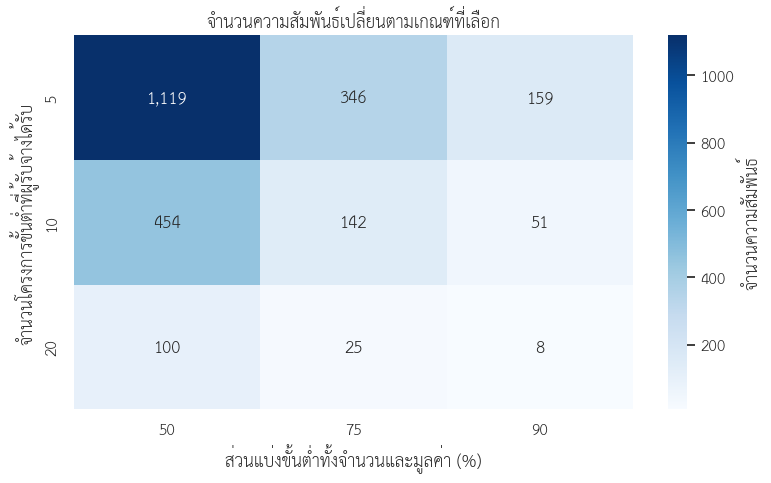

Figure saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_01_supplier_dependence_sensitivity.png


In [76]:
sensitivity_heatmap = (
    concentration_sensitivity
    .pivot(
        index='minimum_projects',
        columns='share_threshold',
        values='relationship_count'
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    sensitivity_heatmap,
    annot=True,
    fmt=',.0f',
    cmap='Blues',
    cbar_kws={'label': 'จำนวนความสัมพันธ์'},
    ax=ax
)

ax.set_title('จำนวนความสัมพันธ์เปลี่ยนตามเกณฑ์ที่เลือก')
ax.set_xlabel('ส่วนแบ่งขั้นต่ำทั้งจำนวนและมูลค่า (%)')
ax.set_ylabel('จำนวนโครงการขั้นต่ำที่ผู้รับจ้างได้รับ')

plt.tight_layout()

figure_path = figure_directory / 'fig04_01_supplier_dependence_sensitivity.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'Figure saved: {figure_path}')


### ผลการทดสอบเกณฑ์พึ่งพาผู้รับจ้าง

เมื่อกำหนดให้ผู้รับจ้างได้อย่างน้อย 10 โครงการและครองอย่างน้อย 75% ทั้งจำนวนและมูลค่า พบ 142 ความสัมพันธ์ ครอบคลุมผู้รับจ้าง 130 รายและ 2,421 โครงการ

จำนวนความสัมพันธ์เปลี่ยนจาก 454 ที่เกณฑ์ 50% เหลือ 51 ที่เกณฑ์ 90% แสดงว่าผลไวต่อ threshold ที่เลือก ค่า 75% จึงเป็นระดับกึ่งกลางสำหรับจัดลำดับงานตรวจ ไม่ใช่เส้นแบ่งตามกฎหมายหรือข้อพิสูจน์ว่าการแข่งขันถูกจำกัด


In [77]:
project_data['flag_material_price_difference'] = (
    project_data['flag_material_above_budget']
    | project_data['flag_material_above_reference']
)

project_data['flag_reference_price_issue'] = (
    project_data['reference_price_status']
    .ne('Within expected range')
)

data_quality_flags = [
    'flag_entity_value_mismatch',
    'flag_reference_price_issue'
]

procurement_review_flags = [
    'flag_material_price_difference',
    'flag_repeated_near_500k_pattern',
    'flag_high_supplier_dependence'
]

project_data['data_quality_indicator_count'] = (
    project_data[data_quality_flags]
    .astype(int)
    .sum(axis=1)
)

project_data['procurement_indicator_count'] = (
    project_data[procurement_review_flags]
    .astype(int)
    .sum(axis=1)
)

study_review_data = project_data.loc[
    project_data['in_study_scope']
].copy()

indicator_count_summary = (
    study_review_data['procurement_indicator_count']
    .value_counts()
    .sort_index()
    .rename_axis('indicator_count')
    .reset_index(name='project_count')
)

indicator_count_summary['project_pct'] = (
    indicator_count_summary['project_count']
    / len(study_review_data)
    * 100
)

display(indicator_count_summary)

indicator_labels = {
    'flag_material_price_difference': 'ส่วนต่างราคา',
    'flag_repeated_near_500k_pattern': 'รูปแบบใกล้เพดานที่เกิดซ้ำ',
    'flag_high_supplier_dependence': 'พึ่งพาผู้รับจ้างสูง'
}

indicator_matrix = (
    study_review_data[procurement_review_flags]
    .astype(bool)
    .rename(columns=indicator_labels)
)

indicator_overlap = indicator_matrix.astype(int).T.dot(
    indicator_matrix.astype(int)
)

display(indicator_overlap)


,indicator_count,project_count,project_pct
0,0,128023,94.09
1,1,7751,5.70
2,2,296,0.22


,ส่วนต่างราคา,รูปแบบใกล้เพดานที่เกิดซ้ำ,พึ่งพาผู้รับจ้างสูง
ส่วนต่างราคา,299,1,4
รูปแบบใกล้เพดานที่เกิดซ้ำ,1,5623,291
พึ่งพาผู้รับจ้างสูง,4,291,2421


## 4. การซ้อนทับและผลการจัดลำดับ

ภายในกลุ่มศึกษาหลัก 136,070 โครงการ พบอย่างน้อยหนึ่งตัวชี้วัด 8,047 โครงการ และพบสองตัวชี้วัด 296 โครงการ จัดเป็นกลุ่มตรวจสอบลำดับแรก

การซ้อนทับประกอบด้วย:

- รูปแบบใกล้เพดานที่เกิดซ้ำร่วมกับการพึ่งพาผู้รับจ้างสูง 291 โครงการ
- ส่วนต่างราคาร่วมกับการพึ่งพาผู้รับจ้างสูง 4 โครงการ
- ส่วนต่างราคาร่วมกับรูปแบบใกล้เพดานที่เกิดซ้ำ 1 โครงการ
- ไม่พบโครงการที่ผ่านครบสามมิติ

“ตรวจสอบลำดับแรก” หมายถึงควรเปิดเอกสารก่อน ไม่ได้หมายความว่าเป็นโครงการทุจริต


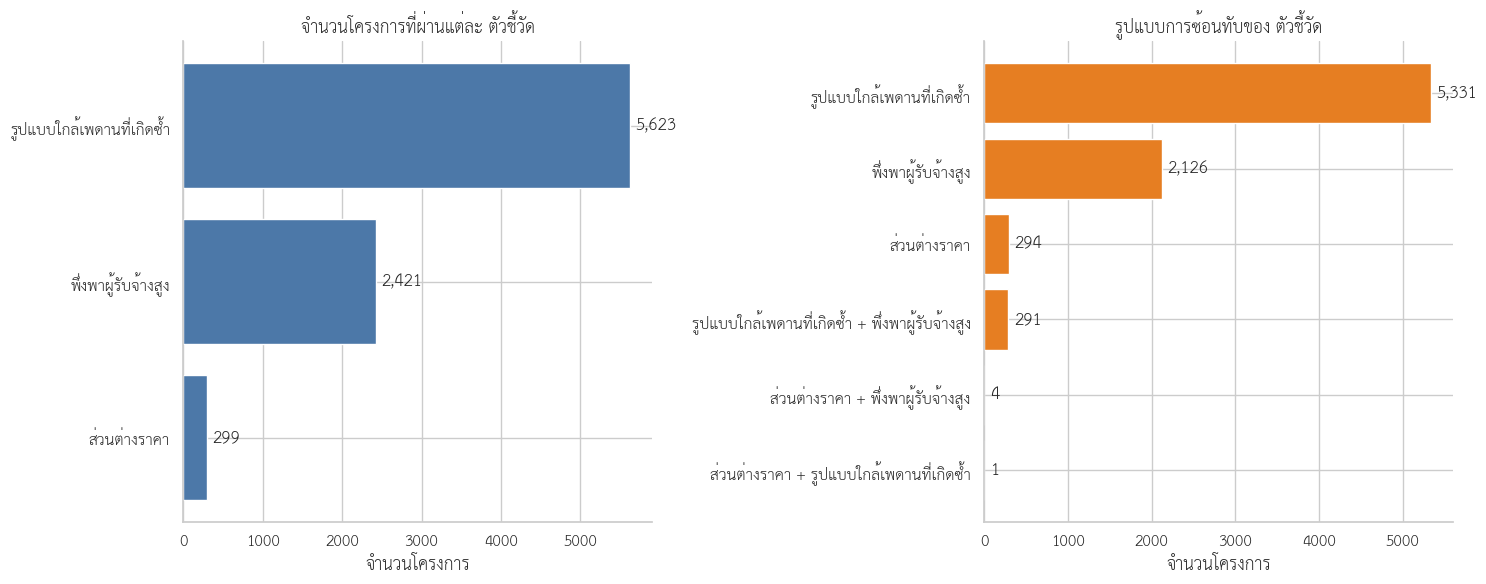

บันทึกรูป: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_02_indicator_counts_and_combinations.png


In [78]:
indicator_counts = (
    indicator_matrix
    .sum()
    .sort_values(ascending=True)
)

combination_summary = (
    indicator_matrix
    .value_counts()
    .reset_index(name='project_count')
)

combination_summary['combination'] = (
    combination_summary
    .apply(
        lambda row: ' + '.join([
            column
            for column in indicator_matrix.columns
            if row[column]
        ]) or 'ไม่พบ ตัวชี้วัด',
        axis=1
    )
)

flagged_combinations = (
    combination_summary.loc[
        combination_summary['combination'].ne('ไม่พบ ตัวชี้วัด')
    ]
    .sort_values('project_count', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars = axes[0].barh(
    indicator_counts.index,
    indicator_counts.values,
    color='#4C78A8'
)
axes[0].bar_label(bars, fmt='{:,.0f}', padding=4)
axes[0].set_title('จำนวนโครงการที่ผ่านแต่ละ ตัวชี้วัด')
axes[0].set_xlabel('จำนวนโครงการ')
axes[0].set_ylabel('')
axes[0].spines[['top', 'right']].set_visible(False)

bars = axes[1].barh(
    flagged_combinations['combination'],
    flagged_combinations['project_count'],
    color='#E67E22'
)
axes[1].bar_label(bars, fmt='{:,.0f}', padding=4)
axes[1].set_title('รูปแบบการซ้อนทับของ ตัวชี้วัด')
axes[1].set_xlabel('จำนวนโครงการ')
axes[1].set_ylabel('')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()

figure_path = figure_directory / 'fig04_02_indicator_counts_and_combinations.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'บันทึกรูป: {figure_path}')


In [79]:
project_data['review_priority'] = np.select(
    [
        ~project_data['in_study_scope'],
        project_data['procurement_indicator_count'].ge(2),
        project_data['procurement_indicator_count'].eq(1)
    ],
    [
        'นอกขอบเขตศึกษา',
        'ตรวจสอบลำดับแรก',
        'ตรวจสอบตามปกติ'
    ],
    default='ไม่พบ Indicator'
)

study_review_data = project_data.loc[
    project_data['in_study_scope']
].copy()

review_priority_summary = (
    study_review_data
    .groupby('review_priority')
    .agg(
        project_count=(project_id_column, 'count'),
        total_awarded_value=(awarded_price_column, 'sum')
    )
    .reset_index()
)

review_priority_summary['project_pct'] = (
    review_priority_summary['project_count']
    / len(study_review_data)
    * 100
)

review_priority_summary['awarded_value_million'] = (
    review_priority_summary['total_awarded_value']
    / 1_000_000
)

display(review_priority_summary)


,review_priority,project_count,total_awarded_value,project_pct,awarded_value_million
0,ตรวจสอบตามปกติ,7751,"3,291,109,432.09",5.70,"3,291.11"
1,ตรวจสอบลำดับแรก,296,"145,427,180.40",0.22,145.43
2,ไม่พบ Indicator,128023,"34,809,168,573.76",94.09,"34,809.17"


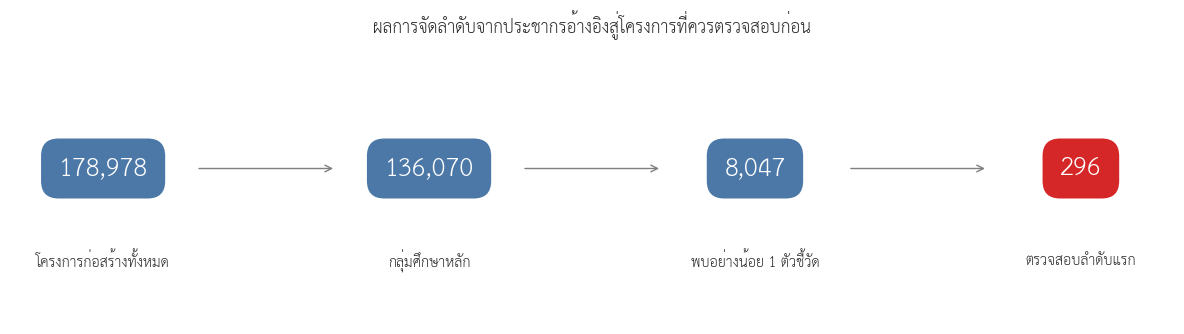

บันทึกรูป: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig04_03_review_prioritization.png


In [80]:
stage_counts = [
    len(project_data),
    project_data['in_study_scope'].sum(),
    (
        study_review_data['procurement_indicator_count']
        .ge(1).sum()
    ),
    (
        study_review_data['procurement_indicator_count']
        .ge(2).sum()
    )
]

stage_labels = [
    'โครงการก่อสร้างทั้งหมด',
    'กลุ่มศึกษาหลัก',
    'พบอย่างน้อย 1 ตัวชี้วัด',
    'ตรวจสอบลำดับแรก'
]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis('off')

x_positions = [0.08, 0.36, 0.64, 0.92]

for index, (x_position, label, count) in enumerate(
    zip(x_positions, stage_labels, stage_counts)
):
    color = '#D62728' if index == 3 else '#4C78A8'
    ax.text(
        x_position,
        0.55,
        f'{count:,.0f}',
        ha='center',
        va='center',
        fontsize=18,
        fontweight='bold',
        color='white',
        bbox={
            'boxstyle': 'round,pad=0.7',
            'facecolor': color,
            'edgecolor': 'none'
        }
    )
    ax.text(
        x_position,
        0.22,
        label,
        ha='center',
        va='center',
        fontsize=10
    )

    if index < len(x_positions) - 1:
        ax.annotate(
            '',
            xy=(x_positions[index + 1] - 0.08, 0.55),
            xytext=(x_position + 0.08, 0.55),
            arrowprops={'arrowstyle': '->', 'color': '#7F7F7F'}
        )

ax.set_title('ผลการจัดลำดับจากประชากรอ้างอิงสู่โครงการที่ควรตรวจสอบก่อน')

plt.tight_layout()

figure_path = figure_directory / 'fig04_03_review_prioritization.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'บันทึกรูป: {figure_path}')


In [81]:
high_priority_columns = [
    project_id_column,
    project_name_column,
    agency_column,
    subagency_column,
    supplier_name_column,
    method_column,
    budget_column,
    reference_price_column,
    awarded_price_column,
    'flag_material_above_budget',
    'flag_material_above_reference',
    'flag_repeated_near_500k_pattern',
    'flag_high_supplier_dependence',
    'procurement_indicator_count',
    'data_quality_indicator_count'
]

high_priority_cases = (
    project_data.loc[
        project_data['review_priority'].eq('ตรวจสอบลำดับแรก'),
        high_priority_columns
    ]
    .sort_values(
        ['procurement_indicator_count', awarded_price_column],
        ascending=False
    )
)

display(high_priority_cases.head(20))


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อผู้ชนะการเสนอราคา,ชื่อวิธีการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),flag_material_above_budget,flag_material_above_reference,flag_repeated_near_500k_pattern,flag_high_supplier_dependence,procurement_indicator_count,data_quality_indicator_count
32840,69049225316,จ้างโครงการปรับปรุงถนนลาดยางผิวทางแอสฟัลต์ติกคอนกรีต Pavement In Place Recycing (สายบ้านวังยาง-บ้านวังดินเหนียว) หมู...,องค์การบริหารส่วนตำบลวังยาง,องค์การบริหารส่วนตำบลวังยาง,ห้างหุ้นส่วนจำกัด กิจเจริญแทรกเตอร์การก่อสร้าง,เฉพาะเจาะจง,"491,000.00","491,000.00","980,000.00",True,True,True,False,2,0
33077,68109248489,จ้างจ้างเหมางานดินขุดด้วยเครื่องจักร จำนวน 1 รายการ อาคารบังคับน้ำห้วยยาง ตำบลไร่ อำเภอพรรณานิคม จังหวัดสกลนคร โดยว...,กรมชลประทาน,โครงการชลประทาน (ชคป.) สกลนคร กรมชลประทาน,ห้างหุ้นส่วนจำกัด ไท้ทองสกลนคร เจริญยิ่ง,เฉพาะเจาะจง,"480,000.00","486,183.40","959,834.40",True,True,False,True,2,0
41447,68119219531,"จ้างปรับปรุงถนนสู่ที่ทำการเกษตรภายในตำบลแซร์ออหมู่ที่ 5,7,10 และหมู่ที่ 13 ตำบลแซร์ออ อำเภอวัฒนานคร จังหวัดสระแก้ว...",เทศบาลตำบลแซร์ออ,เทศบาลตำบลแซร์ออ,ส.พงษ์สมรก่อสร้าง,เฉพาะเจาะจง,"500,000.00","500,000.00","500,000.00",False,False,True,True,2,0
41483,68119221511,"จ้างปรับปรุงถนนสู่ที่ทำการเกษตรภายในตำบลแซร์ออหมู่ที่ 2,3,4,8 และหมู่ที่ 11 ตำบลแซร์ออ อำเภอวัฒนานคร จังหวัดสระแก้...",เทศบาลตำบลแซร์ออ,เทศบาลตำบลแซร์ออ,ส.พงษ์สมรก่อสร้าง,เฉพาะเจาะจง,"500,000.00","500,000.00","500,000.00",False,False,True,True,2,0
41523,68119217138,"จ้างปรับปรุงถนนสู่ที่ทำการเกษตรภายในตำบลแซร์ออหมู่ที่ 6,9,12 และหมู่ที่ 14 ตำบลแซร์ออ ตำบลแซร์ออ อำเภอวัฒนานคร จั...",เทศบาลตำบลแซร์ออ,เทศบาลตำบลแซร์ออ,ส.พงษ์สมรก่อสร้าง,เฉพาะเจาะจง,"500,000.00","500,000.00","500,000.00",False,False,True,True,2,0
42682,68109307158,จ้างโครงการก่อสร้างถนนคอนกรีตเสริมเหล็ก สายห้วยขี้หมาจอก บ้านใหม่ชัยพร หมู่ที่ ๗ โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลพระบุ,เทศบาลตำบลพระบุ,ห้างหุ้นส่วนจำกัด บี จี วิศวกรรม แอนด์ คอนสตรัคชั่น,เฉพาะเจาะจง,"499,600.00","499,840.49","499,600.00",False,False,True,True,2,0
42683,68109306914,จ้างโครงการก่อสร้างถนนคอนกรีตเสริมเหล็ก สายนานางอู้ ถึง โคกน้อยบ้านโพธิ์ขุมดิน หมู่ที่ 2 โดยวิธีเฉพาะเจาะจง,เทศบาลตำบลพระบุ,เทศบาลตำบลพระบุ,ห้างหุ้นส่วนจำกัด บี จี วิศวกรรม แอนด์ คอนสตรัคชั่น,เฉพาะเจาะจง,"499,600.00","499,840.49","499,600.00",False,False,True,True,2,0
45676,69049422975,จ้างปรับปรุงผิวจราจรคอนกรีตเป็นผิวจราจรแอสฟัลท์ติกคอนกรีต หมู่ที่ ๖ บ้านหนองญาติ (สายภายในหมู่ที่ ๖ บ้านหนองญาติ) (จ...,เทศบาลตำบลหนองญาติ,เทศบาลตำบลหนองญาติ,ห้างหุ้นส่วนจำกัด บัญชาศรีสงครามก่อสร้าง,เฉพาะเจาะจง,"499,000.00","499,227.30","499,000.00",False,False,True,True,2,0
45682,69049375009,จ้างซ่อมแซมถนนโดยวิธีแก้ไขผิวทาง Deep patching / Skin patching สายทาง มค.ถ.1-0058 บ้านขี - บ้านหนองโน อำเภอกันทรวิช...,องค์การบริหารส่วนจังหวัดมหาสารคาม,องค์การบริหารส่วนจังหวัดมหาสารคาม,ห้างหุ้นส่วนจำกัด เจริญทรัพย์มหาสารคาม ก่อสร้าง,เฉพาะเจาะจง,"499,000.00","499,816.21","499,000.00",False,False,True,True,2,0
45685,69049374976,จ้างซ่อมแซมถนนโดยวิธีแก้ไขผิวทาง Deep patching / Skin patching สายทาง มค.ถ.1-0045 บ้านหนองแดง - บ้านหลุบเปลือย อำเภอ...,องค์การบริหารส่วนจังหวัดมหาสารคาม,องค์การบริหารส่วนจังหวัดมหาสารคาม,ห้างหุ้นส่วนจำกัด เจริญทรัพย์มหาสารคาม ก่อสร้าง,เฉพาะเจาะจง,"499,000.00","499,434.49","499,000.00",False,False,True,True,2,0


In [82]:
concentration_case = (
    high_dependence_relationships
    .sort_values(
        [
            'project_share_within_subagency_pct',
            'value_share_within_subagency_pct',
            'supplier_project_count'
        ],
        ascending=False
    )
    .head(1)
)

display(concentration_case)

if not concentration_case.empty:
    concentration_case_projects = (
        project_data.loc[
            project_data[subagency_column].eq(
                concentration_case.iloc[0][subagency_column]
            )
            & project_data[supplier_id_column].eq(
                concentration_case.iloc[0][supplier_id_column]
            )
        ]
    )

    display(
        concentration_case_projects[
            [
                project_id_column,
                project_name_column,
                budget_column,
                awarded_price_column,
                transaction_date_column
            ]
        ].head(20)
    )


,ชื่อหน่วยงานย่อย,เลขประจำตัวนิติบุคคล 13 หลัก,supplier_name,supplier_project_count,total_contract_value,subagency_project_count,subagency_contract_value,project_share_within_subagency_pct,value_share_within_subagency_pct
34115,เทศบาลตำบลบ้านโปร่ง,0413555002704,ห้างหุ้นส่วนจำกัด สมจินตนาวงษ์เจริญ คอนกรีต,73,"7,974,800.00",73,"7,974,800.00",100.00,100.00


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),วันที่เกิดรายการ
70483,69049222839,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็ก บ้านตะเคียนทอง หมู่ 9 สายข้างบ้านนางเพ็ญพร โดยวิธีเฉพาะเจาะจง,"471,200.00","471,000.00",22 เม.ย. 69
72271,68129278957,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็ก บ้านสามขา หมู่ 6 สายกลางหมู่บ้านไปทางทิศตะวันตก โดยวิธีเฉพาะเจาะจง,"471,200.00","465,000.00",22 ธ.ค. 68
72276,68129279711,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็ก รหัสทางหลวงท้องถิ่น อด.ถ.28-009 บ้านห้วยผึ้ง หมู่ 10-โสกหินขาว-บ้านโคกล่าม โดยวิธ...,"471,200.00","465,000.00",22 ธ.ค. 68
72926,69019189928,จ้างโครงการก่อสร้างถนนคอนกรีตเสริมเหล็ก บ้านโคกข่า หมู่ ๘ สายหน้าประปาหมู่บ้าน-ถนนรอบหนองกอก ช่วงที่ ๑ โดยวิธีเฉพาะ...,"469,340.00","462,000.00",3 ก.พ. 69
74390,68129269884,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็ก บ้านโพธิ์งาม หมู่ 11 สายแยกทางหลวงท้องถิ่น รหัส อด.ถ 28-001 บ้านตะเคียนทอง-บ้านสมดี...,"464,535.00","456,000.00",22 ธ.ค. 68
78309,68129269914,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็ก บ้านห้วยผึ้ง หมู่ 2 สายรอบหนองห้วยผึ้ง โดยวิธีเฉพาะเจาะจง,"446,400.00","440,000.00",22 ธ.ค. 68
79057,69049224318,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็กบ้านโปร่ง หมู่ 1 สายรอบหมู่บ้านด้านทิศเหนือ โดยวิธีเฉพาะเจาะจง,"436,480.00","436,000.00",22 เม.ย. 69
79457,69059509436,จ้างก่อสร้างถนนคอนกรีตเสริมเหล็ก บ้านโคกล่าม หมู่ ๓ สายรอบหมู่บ้านด้านทิศเหนือข้างไร่นายเพิ่มศักดิ์ โดยวิธีเฉพาะเจาะจง,"434,000.00","433,500.00",10 มิ.ย. 69
83280,69019182786,จ้างโครงการก่อสร้างถนนคอนกรีตเสริมเหล็ก บ้านโคกข่า หมู่ 5 สายรอบหมู่บ้านด้านทิศใต้ โดยวิธีเฉพาะเจาะจง,"419,120.00","412,000.00",3 ก.พ. 69
92438,69069009497,จ้างขยายถนนผิวจราจรคอนกรีตเสริมเหล็ก บ้านสมดี หมู่ 4 สายกลางหมู่บ้าน ข้างที่ 1 ถนนฝั่งขวา โดยวิธีเฉพาะเจาะจง,"363,125.00","363,000.00",10 มิ.ย. 69


In [83]:
# Inspect contract rows of the unique price-and-pattern case
case_project_id = 69049225316

case_contract_data = contract_data.loc[
    contract_data[project_id_column].eq(case_project_id)
].copy()

case_contract_columns = [
    project_id_column,
    project_name_column,
    supplier_id_column,
    supplier_name_column,
    contract_number_column,
    contract_budget_column,
    awarded_price_column,
    'วันที่ลงนามในสัญญา',
    'วันที่สิ้นสุดสัญญา',
    'is_joint_venture_member',
    'source_file'
]

display(
    case_contract_data[
        case_contract_columns
    ].style.format({
        contract_budget_column: '{:,.2f}',
        awarded_price_column: '{:,.2f}'
    })
)

case_contract_summary = pd.DataFrame({
    'value': [
        len(case_contract_data),
        case_contract_data[supplier_id_column].nunique(),
        case_contract_data[contract_number_column].nunique(),
        case_contract_data[contract_budget_column].sum(),
        case_contract_data[awarded_price_column].iloc[0]
    ]
}, index=[
    'Contract-level rows',
    'Unique supplier IDs',
    'Unique contract numbers',
    'Sum of contract values',
    'Project awarded total'
])

display(case_contract_summary)

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วงเงินงบประมาณในสัญญา (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,is_joint_venture_member,source_file
33787,69049225316,จ้างโครงการปรับปรุงถนนลาดยางผิวทางแอสฟัลต์ติกคอนกรีต Pavement In Place Recycing (สายบ้านวังยาง-บ้านวังดินเหนียว) หมู่ที่ ๓ บ้านวังดินเหนียว ตำบลวังยาง อำเภอเนินมะปราง จังหวัดพิษณุโลก โดยวิธีเฉพาะเจาะจง,0663522000051,ห้างหุ้นส่วนจำกัด กิจเจริญแทรกเตอร์การก่อสร้าง,4/2569,"490,000.00","980,000.00",27 พ.ค. 69,26 ก.ค. 69,False,2569-egp-contract-1.csv
33788,69049225316,จ้างโครงการปรับปรุงถนนลาดยางผิวทางแอสฟัลต์ติกคอนกรีต Pavement In Place Recycing (สายบ้านวังยาง-บ้านวังดินเหนียว) หมู่ที่ ๓ บ้านวังดินเหนียว ตำบลวังยาง อำเภอเนินมะปราง จังหวัดพิษณุโลก โดยวิธีเฉพาะเจาะจง,0663522000051,ห้างหุ้นส่วนจำกัด กิจเจริญแทรกเตอร์การก่อสร้าง,9/2569,"490,000.00","980,000.00",17 มิ.ย. 69,16 ส.ค. 69,False,2569-egp-contract-1.csv


,value
Contract-level rows,2.00
Unique supplier IDs,1.00
Unique contract numbers,2.00
Sum of contract values,"980,000.00"
Project awarded total,"980,000.00"


## 5. กรณีศึกษา

### กรณี A: ส่วนต่างราคาและหลายสัญญา

โครงการ `69049225316` มีงบประมาณและราคากลาง 491,000 บาท แต่ราคาที่ตกลงรวม 980,000 บาท ข้อมูลสัญญาพบ 2 ฉบับกับผู้รับจ้างรายเดียว ฉบับละ 490,000 บาท

ยอดสัญญารวมตรงกับยอดระดับโครงการ สิ่งที่ต้องตรวจต่อคือขอบเขตของแต่ละสัญญา แหล่งงบ การอนุมัติเพิ่มหรือแก้ไข และลำดับเหตุการณ์


### กรณี B: รูปแบบใกล้เส้นแบ่งที่เกิดซ้ำ

กลุ่มใหญ่ที่สุดเป็น 65 โครงการของสำนักงานทรัพยากรธรรมชาติและสิ่งแวดล้อมจังหวัดมุกดาหาร ผู้รับจ้างคือบริษัท บ้านบุ่ง วิศวกรรม จำกัด และมีวันที่เกิดรายการ 29 ธันวาคม 2568

ควรตรวจความคล้ายของงาน สถานที่ แผนจัดซื้อ TOR/BOQ และแหล่งงบ ก่อนพิจารณาว่าโครงการมีเหตุผลให้ดำเนินการแยกกันหรือไม่

### กรณี C: ความสัมพันธ์ที่พึ่งพาผู้รับจ้างสูง

เทศบาลตำบลบ้านโปร่งมี 73 โครงการในกลุ่มศึกษา และผู้รับจ้างรายเดียวได้รับครบทั้ง 73 โครงการ คิดเป็น 100% ทั้งจำนวนและมูลค่า รวมประมาณ 7.97 ล้านบาท

ข้อมูลผู้ชนะอย่างเดียวยังอธิบายไม่ได้ว่าเกิดจากการแข่งขันต่ำ ความเชี่ยวชาญ หรือข้อจำกัดด้านพื้นที่ จึงต้องตรวจจำนวนผู้เสนอราคา วิธีเชิญผู้ประกอบการ และความสัมพันธ์ของขอบเขตงาน

### กรณี D: การซ้อนทับหลายมิติ

โครงการตรวจสอบลำดับแรกมี 296 โครงการ โดย 291 โครงการมาจากรูปแบบใกล้เพดานที่เกิดซ้ำร่วมกับการพึ่งพาผู้รับจ้างสูง อีก 5 โครงการเกี่ยวข้องกับส่วนต่างราคา

การนำเสนอควรเลือกอย่างน้อยหนึ่งโครงการจากแต่ละรูปแบบการซ้อนทับ เพื่อครอบคลุมราคา รูปแบบเกิดซ้ำ และการพึ่งพาผู้รับจ้าง


## 6. สรุปผล

| ผลการคัดกรองในกลุ่มศึกษา | จำนวนโครงการ |
|---|---:|
| ส่วนต่างราคา | 299 |
| รูปแบบใกล้เพดานที่เกิดซ้ำ | 5,623 |
| ความสัมพันธ์ที่พึ่งพาผู้รับจ้างสูง | 2,421 |
| พบอย่างน้อย 1 ตัวชี้วัด | 8,047 |
| ตรวจสอบลำดับแรก: พบ 2 ตัวชี้วัด | 296 |

Insight หลักคือการอยู่ใกล้ 500,000 บาทเพียงอย่างเดียวไม่เพียงพอ กลุ่มตรวจสอบลำดับแรกส่วนใหญ่เกิดจากการซ้อนทับระหว่างรูปแบบใกล้เพดานที่เกิดซ้ำกับการพึ่งพาผู้รับจ้างรายเดียวสูงภายในหน่วยงานย่อย

ผลลัพธ์ช่วยลดขอบเขตการเปิดเอกสาร แต่ยังไม่อธิบายสาเหตุหรือพิสูจน์ความผิด


## 7. ข้อจำกัดและการนำผลไปใช้

- ข้อมูลสะสมถึงวันที่ 30 กรกฎาคม 2569 ไม่ใช่ข้อมูลเต็มปี
- มีเฉพาะผู้ชนะ ไม่มีผู้เสนอราคาและราคาที่เสนอทั้งหมด
- วันที่เกิดรายการอาจไม่ใช่วันที่ตัดสินใจจัดซื้อหรือวันที่ลงนาม
- ช่วง 490,000–500,000 บาท, 3 โครงการ, 10,000 บาท, 1%, 10 โครงการ และ 75% เป็นเกณฑ์ของการศึกษา
- ผลการทดสอบความไวแสดงว่าจำนวนที่ถูกคัดกรองเปลี่ยนตาม threshold
- การอยู่ใกล้เส้นแบ่ง การเกิดซ้ำ และการพึ่งพาผู้รับจ้างไม่พิสูจน์เจตนาหรือความผิด
- ต้องตรวจแผนจัดซื้อ TOR/BOQ แหล่งงบ เอกสารอนุมัติ สัญญา และข้อมูลผู้เสนอราคาก่อนสรุปสาเหตุ


In [84]:
# Export review outputs for later reporting
output_directory = processed_dir
output_directory.mkdir(parents=True, exist_ok=True)

project_review_columns = [
    project_id_column,
    project_name_column,
    agency_column,
    subagency_column,
    province_column,
    method_column,
    supplier_id_column,
    supplier_name_column,
    transaction_date_column,
    budget_column,
    reference_price_column,
    awarded_price_column,
    'in_study_scope',
    'reference_price_status',
    'flag_reference_price_issue',
    'flag_entity_value_mismatch',
    'flag_multi_party_contract',
    'budget_overrun',
    'budget_overrun_pct',
    'reference_overrun',
    'reference_overrun_pct',
    'near_500k_cluster_size',
    'flag_material_price_difference',
    'flag_repeated_near_500k_pattern',
    'flag_high_supplier_dependence',
    'data_quality_indicator_count',
    'procurement_indicator_count',
    'review_priority'
]

project_review_output = project_data[
    project_review_columns
].copy()

study_review_output = project_review_output.loc[
    project_review_output['in_study_scope']
].copy()

high_priority_output = project_review_output.loc[
    project_review_output['review_priority']
    .eq('ตรวจสอบลำดับแรก')
].copy()

repeated_cluster_output = (
    near_500k_clusters.loc[
        near_500k_clusters['project_count']
        .ge(minimum_cluster_size)
    ]
    .sort_values(
        ['project_count', 'total_budget'],
        ascending=False
    )
)

output_objects = {
    'project_review_indicators_2569.csv': project_review_output,
    'study_scope_review_indicators_2569.csv': study_review_output,
    'high_priority_projects_2569.csv': high_priority_output,
    'repeated_near_500k_clusters_2569.csv': repeated_cluster_output,
    'high_supplier_dependence_2569.csv': high_dependence_relationships,
    'price_threshold_sensitivity_2569.csv': materiality_sensitivity,
    'near_500k_sensitivity_2569.csv': near_ceiling_sensitivity,
    'supplier_dependence_sensitivity_2569.csv': concentration_sensitivity
}

export_records = []

for file_name, output_data in output_objects.items():
    output_path = output_directory / file_name
    output_data.to_csv(
        output_path,
        index=False,
        encoding='utf-8-sig'
    )
    export_records.append({
        'file_name': file_name,
        'rows': len(output_data),
        'file_size_mb': output_path.stat().st_size / 1024**2
    })

export_summary = pd.DataFrame(export_records)
display(export_summary)


,file_name,rows,file_size_mb
0,project_review_indicators_2569.csv,178978,162.08
1,study_scope_review_indicators_2569.csv,136070,114.65
2,high_priority_projects_2569.csv,296,0.30
3,repeated_near_500k_clusters_2569.csv,1245,0.27
4,high_supplier_dependence_2569.csv,142,0.03
5,price_threshold_sensitivity_2569.csv,24,0.00
6,near_500k_sensitivity_2569.csv,4,0.00
7,supplier_dependence_sensitivity_2569.csv,9,0.00


## 8. ไฟล์ผลลัพธ์

Notebook ส่งออกข้อมูลระดับโครงการ กลุ่มศึกษาหลัก โครงการที่ควรตรวจสอบลำดับแรก กลุ่มเกิดซ้ำ ความสัมพันธ์ที่พึ่งพาผู้รับจ้างสูง และผล sensitivity ของ threshold ทั้งสามชุด

ผลลัพธ์ทั้งหมดเป็นการคัดกรองจากข้อมูล ไม่ใช่หลักฐานหรือข้อสรุปเกี่ยวกับการทุจริต
